# Predicting Residential Property Value Growth in London


## Preprocessing

In [1]:
import pandas as pd

df = pd.read_csv('/content/kaggle_london_house_price_data.csv')

import pandas as pd

# just checking how big the dataset is
print(df.shape)

# i want to see all the column names first
print(df.columns.tolist())

# checking the data type of each column
print(df.dtypes)

# just looking at the first few rows
print(df.head())

# checking which columns have missing values
print(df.isnull().sum().sort_values(ascending=False))

(418201, 28)
['fullAddress', 'postcode', 'country', 'outcode', 'latitude', 'longitude', 'bathrooms', 'bedrooms', 'floorAreaSqM', 'livingRooms', 'tenure', 'propertyType', 'currentEnergyRating', 'rentEstimate_lowerPrice', 'rentEstimate_currentPrice', 'rentEstimate_upperPrice', 'saleEstimate_lowerPrice', 'saleEstimate_currentPrice', 'saleEstimate_upperPrice', 'saleEstimate_confidenceLevel', 'saleEstimate_ingestedAt', 'saleEstimate_valueChange.numericChange', 'saleEstimate_valueChange.percentageChange', 'saleEstimate_valueChange.saleDate', 'history_date', 'history_price', 'history_percentageChange', 'history_numericChange']
fullAddress                                   object
postcode                                      object
country                                       object
outcode                                       object
latitude                                     float64
longitude                                    float64
bathrooms                                    float64
b

In [2]:
import pandas as pd
import os

# i'm loading the dataset from colab files
file_path = "/content/kaggle_london_house_price_data.csv"

dtype_map = {
    "fullAddress": "string",
    "postcode": "string",
    "country": "string",
    "outcode": "string",
    "tenure": "string",
    "propertyType": "string",
    "currentEnergyRating": "string",
    "saleEstimate_confidenceLevel": "string"
}

df = pd.read_csv(file_path, dtype=dtype_map)

# i'm creating a unique id so i can split and merge later
df.insert(0, "property_id", range(1, len(df) + 1))

print("dataset shape:", df.shape)
print("\ncolumns:")
print(df.columns.tolist())
print("\nfirst 3 rows:")
display(df.head(3))

dataset shape: (418201, 29)

columns:
['property_id', 'fullAddress', 'postcode', 'country', 'outcode', 'latitude', 'longitude', 'bathrooms', 'bedrooms', 'floorAreaSqM', 'livingRooms', 'tenure', 'propertyType', 'currentEnergyRating', 'rentEstimate_lowerPrice', 'rentEstimate_currentPrice', 'rentEstimate_upperPrice', 'saleEstimate_lowerPrice', 'saleEstimate_currentPrice', 'saleEstimate_upperPrice', 'saleEstimate_confidenceLevel', 'saleEstimate_ingestedAt', 'saleEstimate_valueChange.numericChange', 'saleEstimate_valueChange.percentageChange', 'saleEstimate_valueChange.saleDate', 'history_date', 'history_price', 'history_percentageChange', 'history_numericChange']

first 3 rows:


,property_id,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,1,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,2,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,3,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN


## 3-Table Business Schema

for me to align the dataset with the project requirement of using at least three files/tables, the original raw housing dataset was reorganized into three linked business tables using `property_id` as the common key.

| Table Name | Business Meaning | Main Columns |
|---|---|---|
| `property_profile` | what the property is | outcode, latitude, longitude, bathrooms, bedrooms, floorAreaSqM, livingRooms, tenure, propertyType, currentEnergyRating |
| `market_estimates` | what the market thinks it is worth | rentEstimate_currentPrice, saleEstimate_currentPrice, saleEstimate_confidenceLevel, estimate ranges |
| `transaction_history` | what it actually sold for | history_date, history_price, history_percentageChange, history_numericChange |

The three-table structure makes the project easier to explain from a business perspective:
- `property_profile` captures physical and location characteristics
- `market_estimates` captures platform-based valuation signals
- `transaction_history` captures the actual observed transaction outcome

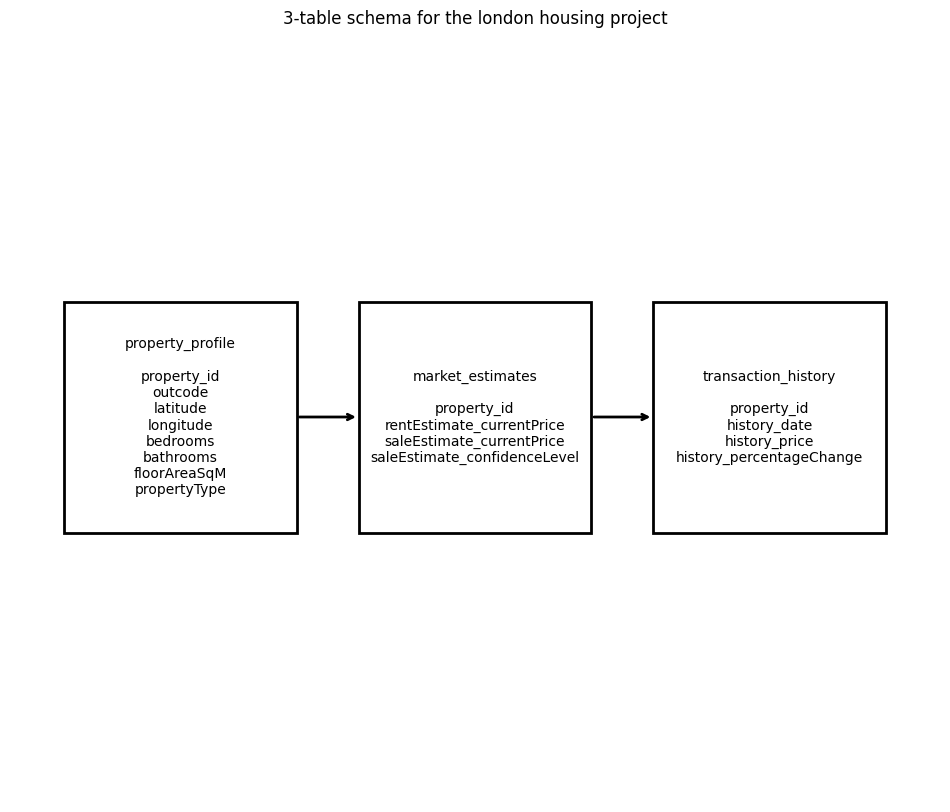

In [90]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

#drawing a simple schema diagram so the 3-table design is easier to understand and i want to use it for my presentation
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

boxes = [
    (0.7, 2.1, 3.0, 1.8, "property_profile\n\nproperty_id\noutcode\nlatitude\nlongitude\nbedrooms\nbathrooms\nfloorAreaSqM\npropertyType"),
    (4.5, 2.1, 3.0, 1.8, "market_estimates\n\nproperty_id\nrentEstimate_currentPrice\nsaleEstimate_currentPrice\nsaleEstimate_confidenceLevel"),
    (8.3, 2.1, 3.0, 1.8, "transaction_history\n\nproperty_id\nhistory_date\nhistory_price\nhistory_percentageChange")
]

for x, y, w, h, label in boxes:
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=10)

ax.annotate("", xy=(4.5, 3.0), xytext=(3.7, 3.0), arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(8.3, 3.0), xytext=(7.5, 3.0), arrowprops=dict(arrowstyle="->", linewidth=2))

plt.title("3-table schema for the london housing project")
plt.show()

In [3]:
# table 1 = what the property is
property_profile = df[
    [
        "property_id",
        "fullAddress",
        "postcode",
        "country",
        "outcode",
        "latitude",
        "longitude",
        "bathrooms",
        "bedrooms",
        "floorAreaSqM",
        "livingRooms",
        "tenure",
        "propertyType",
        "currentEnergyRating"
    ]
].copy()

# table 2 = what the market thinks it is worth
market_estimates = df[
    [
        "property_id",
        "rentEstimate_lowerPrice",
        "rentEstimate_currentPrice",
        "rentEstimate_upperPrice",
        "saleEstimate_lowerPrice",
        "saleEstimate_currentPrice",
        "saleEstimate_upperPrice",
        "saleEstimate_confidenceLevel",
        "saleEstimate_ingestedAt",
        "saleEstimate_valueChange.numericChange",
        "saleEstimate_valueChange.percentageChange",
        "saleEstimate_valueChange.saleDate"
    ]
].copy()

# table 3 = what it actually sold for
transaction_history = df[
    [
        "property_id",
        "history_date",
        "history_price",
        "history_percentageChange",
        "history_numericChange"
    ]
].copy()

print("property_profile shape:", property_profile.shape)
print("market_estimates shape:", market_estimates.shape)
print("transaction_history shape:", transaction_history.shape)

property_profile shape: (418201, 14)
market_estimates shape: (418201, 12)
transaction_history shape: (418201, 5)


In [4]:
# im saving the split tables so i can use them separately later
output_folder = "/content/split_tables"
os.makedirs(output_folder, exist_ok=True)

property_profile.to_csv(f"{output_folder}/property_profile.csv", index=False)
market_estimates.to_csv(f"{output_folder}/market_estimates.csv", index=False)
transaction_history.to_csv(f"{output_folder}/transaction_history.csv", index=False)

property_profile.to_parquet(f"{output_folder}/property_profile.parquet", index=False)
market_estimates.to_parquet(f"{output_folder}/market_estimates.parquet", index=False)
transaction_history.to_parquet(f"{output_folder}/transaction_history.parquet", index=False)

print("all 3 tables saved successfully in:", output_folder)

all 3 tables saved successfully in: /content/split_tables


## exploratory analysis & data cleaning

In [5]:
#im checking that all tables still line up by property_id
print("unique ids in full data:", df["property_id"].nunique())
print("unique ids in property table:", property_profile["property_id"].nunique())
print("unique ids in market table:", market_estimates["property_id"].nunique())
print("unique ids in history table:", transaction_history["property_id"].nunique())

print("\nmissing property_id values:")
print("property table:", property_profile["property_id"].isna().sum())
print("market table:", market_estimates["property_id"].isna().sum())
print("history table:", transaction_history["property_id"].isna().sum())

unique ids in full data: 418201
unique ids in property table: 418201
unique ids in market table: 418201
unique ids in history table: 418201

missing property_id values:
property table: 0
market table: 0
history table: 0


I split the original dataset into three project-ready tables that clearly separate property characteristics, market estimates, and actual sales outcomes. adding property_id gives us a safe common key for merging later, which makes the structure cleaner and easier to justify in the presentation. this also satisfies the multi-table requirement in a way that looks intentional and well designed.

In [6]:
# i'm checking quality issues before i start cleaning anything
for table_name, table_df in {
    "property_profile": property_profile,
    "market_estimates": market_estimates,
    "transaction_history": transaction_history
}.items():
    print(f"\n{'='*60}")
    print(f"{table_name.upper()}")
    print(f"{'='*60}")

    print("\nshape:")
    print(table_df.shape)

    print("\ndtypes:")
    print(table_df.dtypes)

    print("\nmissing values:")
    missing = table_df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(missing)
    else:
        print("no missing values")


PROPERTY_PROFILE

shape:
(418201, 14)

dtypes:
property_id                     int64
fullAddress            string[python]
postcode               string[python]
country                string[python]
outcode                string[python]
latitude                      float64
longitude                     float64
bathrooms                     float64
bedrooms                      float64
floorAreaSqM                  float64
livingRooms                   float64
tenure                 string[python]
propertyType           string[python]
currentEnergyRating    string[python]
dtype: object

missing values:
currentEnergyRating    84526
bathrooms              77931
livingRooms            60500
bedrooms               40536
floorAreaSqM           25210
tenure                 11512
propertyType            1136
dtype: int64

MARKET_ESTIMATES

shape:
(418201, 12)

dtypes:
property_id                                           int64
rentEstimate_lowerPrice                             float64
rentE

In [7]:
# im checking whether any rows got repeated inside each table
for table_name, table_df in {
    "property_profile": property_profile,
    "market_estimates": market_estimates,
    "transaction_history": transaction_history
}.items():
    print(f"\n{table_name} duplicate rows:", table_df.duplicated().sum())
    print(f"{table_name} duplicate property_id values:", table_df["property_id"].duplicated().sum())


property_profile duplicate rows: 0
property_profile duplicate property_id values: 0

market_estimates duplicate rows: 0
market_estimates duplicate property_id values: 0

transaction_history duplicate rows: 0
transaction_history duplicate property_id values: 0


In [8]:
# getting a safe numeric summary so i can spot weird values early
key_numeric_cols = [
    "bathrooms", "bedrooms", "floorAreaSqM", "livingRooms",
    "rentEstimate_currentPrice", "saleEstimate_currentPrice",
    "history_price", "history_percentageChange", "history_numericChange"
]

existing_numeric_cols = []
for col in key_numeric_cols:
    if col in df.columns:
        existing_numeric_cols.append(col)

print(df[existing_numeric_cols].describe().T)

                              count           mean           std  \
bathrooms                  340270.0       1.444265  7.244781e-01   
bedrooms                   377665.0       2.474884  1.160506e+00   
floorAreaSqM               392991.0      98.926543  5.593891e+01   
livingRooms                357701.0       1.282275  5.744118e-01   
rentEstimate_currentPrice  416460.0    3639.487466  3.487802e+03   
saleEstimate_currentPrice  417561.0  904518.762528  9.202917e+05   
history_price              418201.0  639584.004390  1.327933e+06   
history_percentageChange   237982.0     105.877778  3.388499e+02   
history_numericChange      237982.0  252874.079405  8.024032e+05   

                                    min            25%            50%  \
bathrooms                  1.000000e+00       1.000000       1.000000   
bedrooms                   1.000000e+00       2.000000       2.000000   
floorAreaSqM               1.000000e+01      63.000000      84.000000   
livingRooms                

In [9]:
# checking the main categories so i know what i'm dealing with
categorical_cols = [
    "propertyType", "tenure", "currentEnergyRating",
    "saleEstimate_confidenceLevel", "outcode"
]

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{'-'*50}")
        print(f"{col}")
        print(df[col].value_counts(dropna=False).head(10))


--------------------------------------------------
propertyType
propertyType
Purpose Built Flat     110096
Flat/Maisonette        100336
Mid Terrace House       68864
Converted Flat          49364
Semi-Detached House     30085
Terrace Property        24195
End Terrace House       20048
Detached House           9862
Terraced                 1702
<NA>                     1136
Name: count, dtype: Int64

--------------------------------------------------
tenure
tenure
Leasehold    247137
Freehold     154507
<NA>          11512
Feudal         3711
Shared         1334
Name: count, dtype: Int64

--------------------------------------------------
currentEnergyRating
currentEnergyRating
D       135656
C       125555
<NA>     84526
B        38589
E        30519
F         2291
G          719
A          346
Name: count, dtype: Int64

--------------------------------------------------
saleEstimate_confidenceLevel
saleEstimate_confidenceLevel
HIGH      300772
MEDIUM     84541
LOW        32248
<NA> 

In [10]:
# merging only the fields i actually want for modeling so i keep things lighter
model_df = property_profile[
    [
        "property_id",
        "outcode",
        "latitude",
        "longitude",
        "bathrooms",
        "bedrooms",
        "floorAreaSqM",
        "livingRooms",
        "tenure",
        "propertyType",
        "currentEnergyRating"
    ]
].merge(
    market_estimates[
        [
            "property_id",
            "rentEstimate_currentPrice",
            "saleEstimate_currentPrice",
            "saleEstimate_confidenceLevel"
        ]
    ],
    on="property_id",
    how="inner"
).merge(
    transaction_history[
        [
            "property_id",
            "history_price"
        ]
    ],
    on="property_id",
    how="inner"
)

print("model_df shape:", model_df.shape)
display(model_df.head())

model_df shape: (418201, 15)


,property_id,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,rentEstimate_currentPrice,saleEstimate_currentPrice,saleEstimate_confidenceLevel,history_price
0,1,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Leasehold,Purpose Built Flat,<NA>,2350.0,600000.0,HIGH,830000
1,2,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,Leasehold,Flat/Maisonette,<NA>,2350.0,600000.0,MEDIUM,830000
2,3,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,Leasehold,Flat/Maisonette,C,2950.0,759000.0,MEDIUM,249950
3,4,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,Leasehold,Flat/Maisonette,D,2000.0,388000.0,HIGH,32000
4,5,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,Freehold,End Terrace House,D,4850.0,1261000.0,HIGH,133000


In [11]:
# check the actual modeling dataset now instead of the raw tables
missing_model = model_df.isna().sum().sort_values(ascending=False)
missing_model = missing_model[missing_model > 0]

print("missing values in model_df:")
print(missing_model)

missing values in model_df:
currentEnergyRating             84526
bathrooms                       77931
livingRooms                     60500
bedrooms                        40536
floorAreaSqM                    25210
tenure                          11512
rentEstimate_currentPrice        1741
propertyType                     1136
saleEstimate_currentPrice         640
saleEstimate_confidenceLevel      640
dtype: int64


In [12]:
# i'm checking the target before i decide on transformations later
print(model_df["history_price"].describe())

print("\nrows with history_price <= 0:", (model_df["history_price"] <= 0).sum())
print("rows with saleEstimate_currentPrice <= 0:", (model_df["saleEstimate_currentPrice"] <= 0).sum())
print("rows with rentEstimate_currentPrice <= 0:", (model_df["rentEstimate_currentPrice"] <= 0).sum())

count    4.182010e+05
mean     6.395840e+05
std      1.327933e+06
min      1.000000e+04
25%      2.280000e+05
50%      4.000000e+05
75%      6.650000e+05
max      1.058000e+08
Name: history_price, dtype: float64

rows with history_price <= 0: 0
rows with saleEstimate_currentPrice <= 0: 0
rows with rentEstimate_currentPrice <= 0: 0


In [13]:
# ooking at category sizes so i know whether some groups are too tiny
for col in ["propertyType", "tenure", "currentEnergyRating", "saleEstimate_confidenceLevel", "outcode"]:
    print(f"\n{'-'*50}")
    print(col)
    print("unique values:", model_df[col].nunique(dropna=True))
    print(model_df[col].value_counts(dropna=False).head(15))


--------------------------------------------------
propertyType
unique values: 19
propertyType
Purpose Built Flat        110096
Flat/Maisonette           100336
Mid Terrace House          68864
Converted Flat             49364
Semi-Detached House        30085
Terrace Property           24195
End Terrace House          20048
Detached House              9862
Terraced                    1702
<NA>                        1136
Semi-Detached Property       497
Bungalow Property            413
Semi-Detached Bungalow       353
Detached Bungalow            283
Detached Property            262
Name: count, dtype: Int64

--------------------------------------------------
tenure
unique values: 4
tenure
Leasehold    247137
Freehold     154507
<NA>          11512
Feudal         3711
Shared         1334
Name: count, dtype: Int64

--------------------------------------------------
currentEnergyRating
unique values: 7
currentEnergyRating
D       135656
C       125555
<NA>     84526
B        38589
E    

In [14]:
import numpy as np

# making a copy so i keep my original modeling table untouched
model_df_clean = model_df.copy()

numeric_cols = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "rentEstimate_currentPrice",
    "saleEstimate_currentPrice"
]

categorical_cols = [
    "outcode",
    "tenure",
    "propertyType",
    "currentEnergyRating",
    "saleEstimate_confidenceLevel"
]

# filling numeric gaps with the median because it's stable and cheap
for col in numeric_cols:
    median_value = model_df_clean[col].median()
    model_df_clean[col] = model_df_clean[col].fillna(median_value)

# filling categorical gaps with unknown so i don't throw away rows
for col in categorical_cols:
    model_df_clean[col] = model_df_clean[col].fillna("unknown")

# creating a log target because house prices are clearly skewed
model_df_clean["log_history_price"] = np.log1p(model_df_clean["history_price"])

print("cleaned dataset shape:", model_df_clean.shape)
print("\nmissing values after cleaning:")
print(model_df_clean.isna().sum()[model_df_clean.isna().sum() > 0])
display(model_df_clean.head())

cleaned dataset shape: (418201, 16)

missing values after cleaning:
Series([], dtype: int64)


,property_id,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,rentEstimate_currentPrice,saleEstimate_currentPrice,saleEstimate_confidenceLevel,history_price,log_history_price
0,1,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Leasehold,Purpose Built Flat,unknown,2350.0,600000.0,HIGH,830000,13.629182
1,2,EC4A,51.517282,-0.110314,1.0,2.0,84.0,1.0,Leasehold,Flat/Maisonette,unknown,2350.0,600000.0,MEDIUM,830000,13.629182
2,3,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,Leasehold,Flat/Maisonette,C,2950.0,759000.0,MEDIUM,249950,12.429020
3,4,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,Leasehold,Flat/Maisonette,D,2000.0,388000.0,HIGH,32000,10.373522
4,5,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,Freehold,End Terrace House,D,4850.0,1261000.0,HIGH,133000,11.798112


In [91]:
#converting the transaction date so i can analyze price trends over time
transaction_history["history_date"] = pd.to_datetime(
    transaction_history["history_date"],
    errors="coerce"
)

print(transaction_history["history_date"].min())
print(transaction_history["history_date"].max())
print(transaction_history["history_date"].isna().sum())

1995-01-02 00:00:00
2024-09-27 00:00:00
0


In [92]:
#extracting the sale year to study how prices changed over time
time_df = transaction_history[["property_id", "history_date", "history_price"]].copy()
time_df = time_df.dropna(subset=["history_date"])

time_df["history_year"] = time_df["history_date"].dt.year

yearly_summary = (
    time_df.groupby("history_year")
    .agg(
        transaction_count=("history_price", "size"),
        median_price=("history_price", "median"),
        mean_price=("history_price", "mean")
    )
    .reset_index()
)

display(yearly_summary.head(10))
display(yearly_summary.tail(10))

,history_year,transaction_count,median_price,mean_price
0,1995,6667,78000.0,121134.826609
1,1996,8403,85000.0,128246.231465
2,1997,10482,100000.0,151390.645965
3,1998,10206,115000.0,176217.849010
4,1999,12030,139950.0,196509.457024
5,2000,10668,162000.0,236745.778965
6,2001,11188,180000.0,255334.395066
7,2002,12261,209200.0,288320.251529
8,2003,10196,216583.5,299659.829639
9,2004,11075,235000.0,323712.013905


,history_year,transaction_count,median_price,mean_price
20,2015,12256,475000.0,825765.465813
21,2016,11954,504750.0,821561.502259
22,2017,12018,530000.0,907241.943418
23,2018,12385,535000.0,964975.393379
24,2019,12003,530500.0,982549.642673
25,2020,12461,560000.0,990664.063398
26,2021,25577,570000.0,919834.999257
27,2022,41497,575000.0,916409.223366
28,2023,54451,552000.0,841250.077005
29,2024,27281,545000.0,777553.641362


In [93]:
# comparing the original target with the log version
print("original target summary:")
print(model_df_clean["history_price"].describe())

print("\nlog target summary:")
print(model_df_clean["log_history_price"].describe())

original target summary:
count    4.182010e+05
mean     6.395840e+05
std      1.327933e+06
min      1.000000e+04
25%      2.280000e+05
50%      4.000000e+05
75%      6.650000e+05
max      1.058000e+08
Name: history_price, dtype: float64

log target summary:
count    418201.000000
mean         12.879559
std           0.924277
min           9.210440
25%          12.337105
50%          12.899222
75%          13.407544
max          18.477061
Name: log_history_price, dtype: float64


In [94]:
#creating a few safe engineered features that may help the model capture market structure better
model_df_fe = model_df_clean.copy()

model_df_fe["price_per_sqm_estimate"] = (
    model_df_fe["saleEstimate_currentPrice"] / model_df_fe["floorAreaSqM"]
)

model_df_fe["rent_yield_proxy"] = (
    (model_df_fe["rentEstimate_currentPrice"] * 12) / model_df_fe["saleEstimate_currentPrice"]
)

model_df_fe["total_rooms"] = (
    model_df_fe["bedrooms"] + model_df_fe["bathrooms"] + model_df_fe["livingRooms"]
)

model_df_fe["sqm_per_room"] = (
    model_df_fe["floorAreaSqM"] / model_df_fe["total_rooms"].replace(0, np.nan)
)

model_df_fe["sale_estimate_range"] = (
    df["saleEstimate_upperPrice"] - df["saleEstimate_lowerPrice"]
)

model_df_fe["history_date"] = pd.to_datetime(df["history_date"], errors="coerce")
model_df_fe["history_year"] = model_df_fe["history_date"].dt.year
model_df_fe["history_month"] = model_df_fe["history_date"].dt.month

print(model_df_fe[[
    "price_per_sqm_estimate",
    "rent_yield_proxy",
    "total_rooms",
    "sqm_per_room",
    "sale_estimate_range",
    "history_year",
    "history_month"
]].describe())

       price_per_sqm_estimate  rent_yield_proxy    total_rooms   sqm_per_room  \
count           418201.000000     418201.000000  418201.000000  418201.000000   
mean              9010.441919          0.050563       5.031769      19.251292   
std               6469.213929          0.007013       1.932359       6.808542   
min                503.012048          0.004805       3.000000       1.076923   
25%               6005.586592          0.046057       4.000000      15.750000   
50%               7594.202899          0.050407       4.000000      18.333333   
75%              10045.454545          0.054545       6.000000      21.000000   
max             309892.857143          0.150725      25.000000     166.666667   

       sale_estimate_range   history_year  history_month  
count         4.175610e+05  418201.000000  418201.000000  
mean          1.464941e+05    2013.143412       6.645687  
std           2.742818e+05       9.310191       3.361889  
min           9.000000e+03    1995

In [95]:
#filling any remaining gaps from the new engineered columns
new_numeric_cols = [
    "price_per_sqm_estimate",
    "rent_yield_proxy",
    "total_rooms",
    "sqm_per_room",
    "sale_estimate_range",
    "history_year",
    "history_month"
]

for col in new_numeric_cols:
    model_df_fe[col] = model_df_fe[col].replace([np.inf, -np.inf], np.nan)
    model_df_fe[col] = model_df_fe[col].fillna(model_df_fe[col].median())

print(model_df_fe[new_numeric_cols].isna().sum())

price_per_sqm_estimate    0
rent_yield_proxy          0
total_rooms               0
sqm_per_room              0
sale_estimate_range       0
history_year              0
history_month             0
dtype: int64


In [96]:
# check whether the log target looks less skewed
print("skew of history_price:", model_df_clean["history_price"].skew())
print("skew of log_history_price:", model_df_clean["log_history_price"].skew())

skew of history_price: 22.49265330621782
skew of log_history_price: 0.12619212794110804


### Time-based Analysis
the time-based analysis adds an important market context. by examining both median sale price and transaction volume over time, the project can show whether the dataset reflects stable pricing periods, growth phases, or shifts in market activity, which makes the business analysis more complete before modeling.

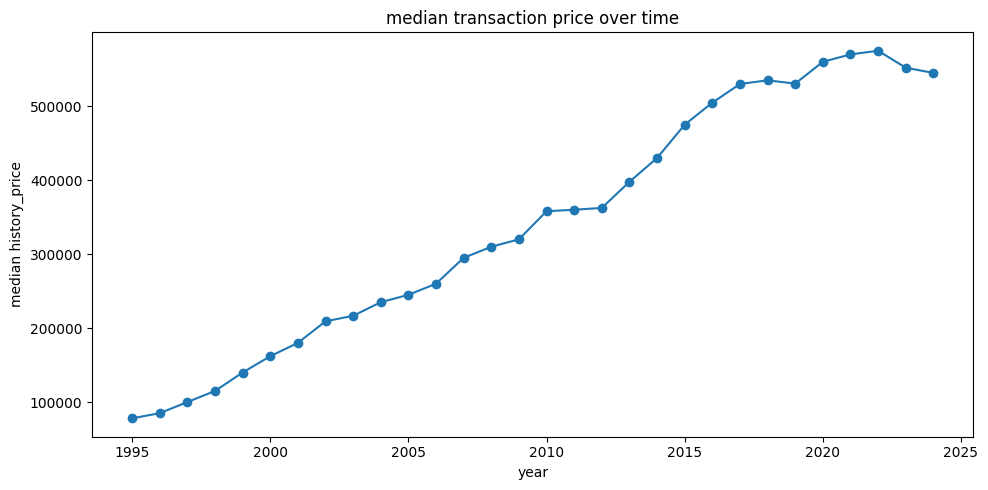

In [97]:
plt.figure(figsize=(10, 5))
plt.plot(yearly_summary["history_year"], yearly_summary["median_price"], marker="o")
plt.title("median transaction price over time")
plt.xlabel("year")
plt.ylabel("median history_price")
plt.tight_layout()
plt.show()

median price rises from about £80k in 1995 to roughly £570k in 2022, which is more than a 7x increase over the period.
growth is especially strong from 2013 to 2017, where the median moves from about £400k to £530k, a gain of around £130k.
after peaking near £570k in 2022, prices soften a bit to about £545k by 2024, so the trend is still high but no longer accelerating.

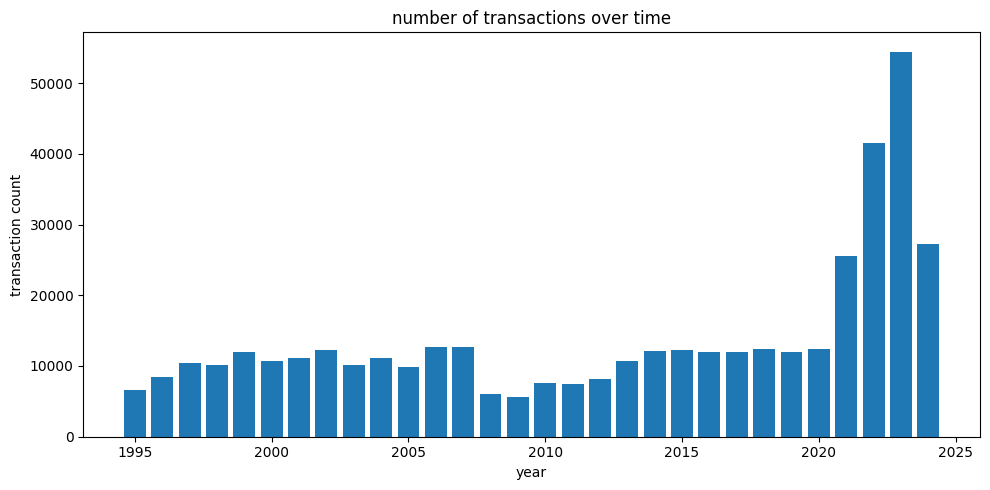

In [98]:
plt.figure(figsize=(10, 5))
plt.bar(yearly_summary["history_year"], yearly_summary["transaction_count"])
plt.title("number of transactions over time")
plt.xlabel("year")
plt.ylabel("transaction count")
plt.tight_layout()
plt.show()

transaction volume is fairly steady for most of the history, often around 6k to 13k per year from 1995 to 2021.
then there is a sharp jump to about 25k in 2021, 41k in 2022, and a peak near 55k in 2023, before dropping to about 27k in 2024.
that surge is too large to look like normal market growth alone, so it may reflect better data coverage, delayed registrations, or a genuine burst in activity.

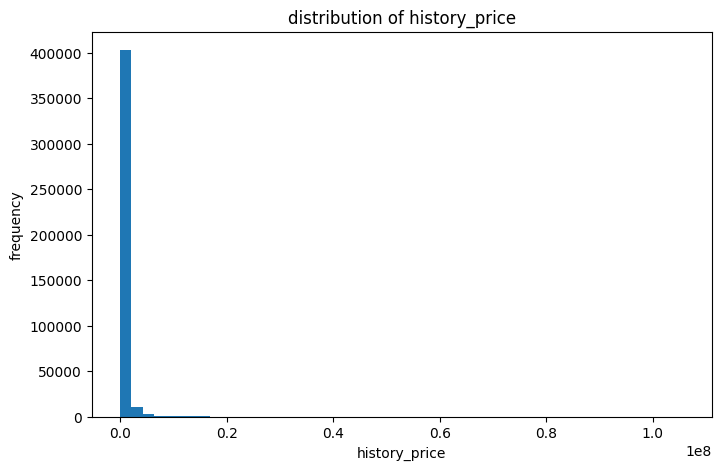

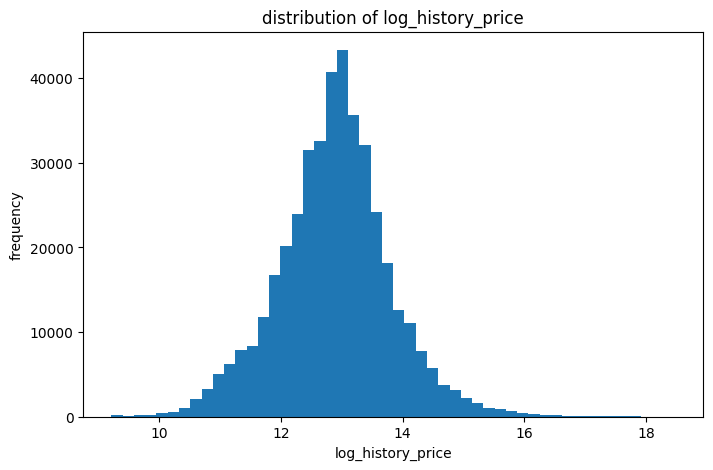

In [99]:
import matplotlib.pyplot as plt

# plotting the target before the log transform
plt.figure(figsize=(8, 5))
plt.hist(model_df_clean["history_price"], bins=50)
plt.title("distribution of history_price")
plt.xlabel("history_price")
plt.ylabel("frequency")
plt.show()

# plotting the target after the log transform
plt.figure(figsize=(8, 5))
plt.hist(model_df_clean["log_history_price"], bins=50)
plt.title("distribution of log_history_price")
plt.xlabel("log_history_price")
plt.ylabel("frequency")
plt.show()

the histograms strongly justify using the log target because the original history_price distribution is extremely right-skewed, with most values compressed near the lower end and a very long tail reaching 105.8 million, while the median is only 400,000 and the mean is 639,584, showing heavy distortion from high-end outliers. after transformation, log_history_price becomes much more symmetric and bell-shaped, which is also confirmed numerically by the skew dropping from 22.49 to 0.13. this is strong evidence that the log version is a far more stable target for regression, since it reduces the influence of extreme properties and makes the learning pattern more balanced across the dataset.

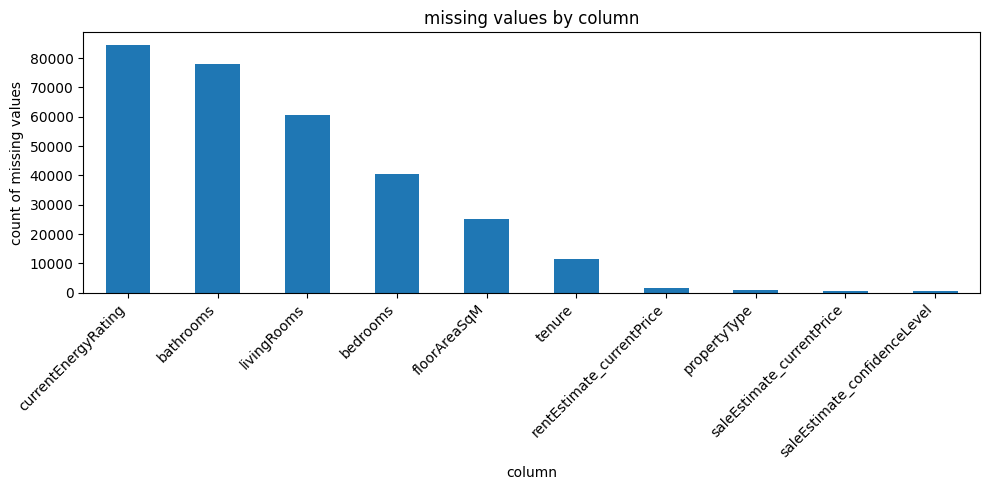

In [100]:
import matplotlib.pyplot as plt

# plotting missing values so i can show data quality issues clearly
missing_counts = model_df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_counts.plot(kind="bar")
plt.title("missing values by column")
plt.xlabel("column")
plt.ylabel("count of missing values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

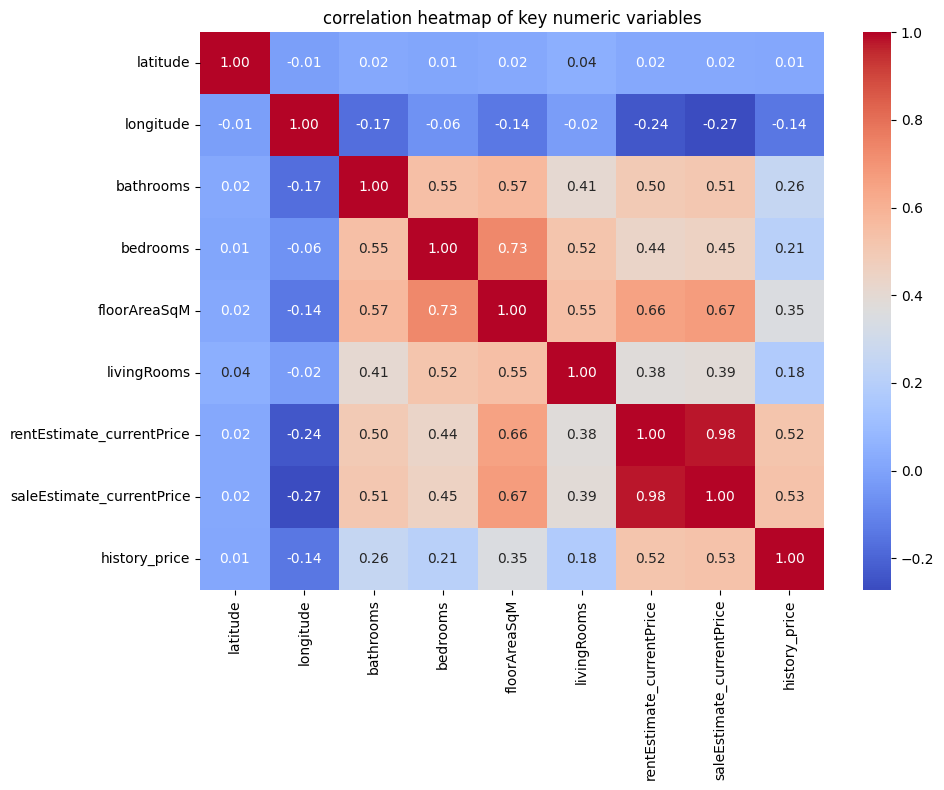

In [101]:
import seaborn as sns

# ill use only the main numeric columns so the heatmap stays readable
numeric_eda_cols = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "rentEstimate_currentPrice",
    "saleEstimate_currentPrice",
    "history_price"
]

corr_matrix = model_df_clean[numeric_eda_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation heatmap of key numeric variables")
plt.tight_layout()
plt.show()

size and room variables move together strongly, especially bedrooms with floorareasqm at 0.73 and bathrooms with floorareasqm at 0.57.
actual sale price is most tied to size, with saleestimate_currentprice correlating 0.67 with floorareasqm and 0.45 with bedrooms.
the standout is rentestimate_currentprice vs saleestimate_currentprice at 0.98, which means those two estimates are almost tracking the same market signal.

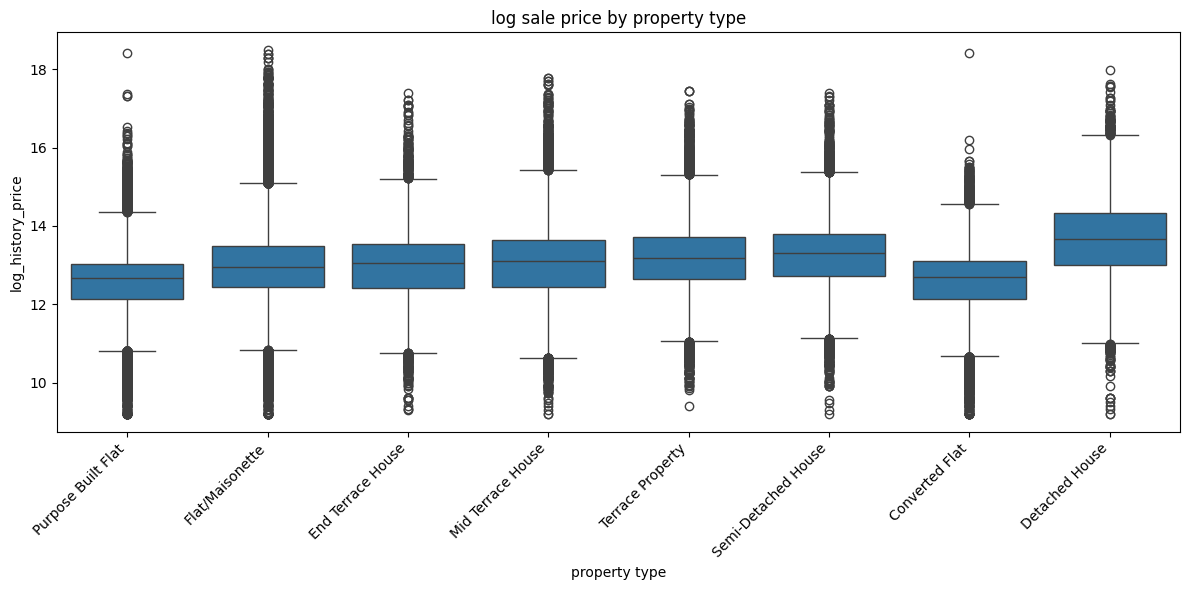

In [102]:
# focusing on the biggest property types so the plot stays readable
top_property_types = model_df_clean["propertyType"].value_counts().head(8).index
plot_df = model_df_clean[model_df_clean["propertyType"].isin(top_property_types)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="propertyType", y="log_history_price")
plt.title("log sale price by property type")
plt.xlabel("property type")
plt.ylabel("log_history_price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

detached house has the highest typical prices, with a median around 13.6 to 13.8 on the log scale, clearly above purpose built flat and converted flat around 12.6 to 12.8.
semi-detached house and terrace property sit in the middle at roughly 13.2 to 13.4, so they are pricier than flats but below detached homes.
there are lots of outliers across every type, with top points reaching about 17.5 to 18.5, so each category still has some very expensive sales.

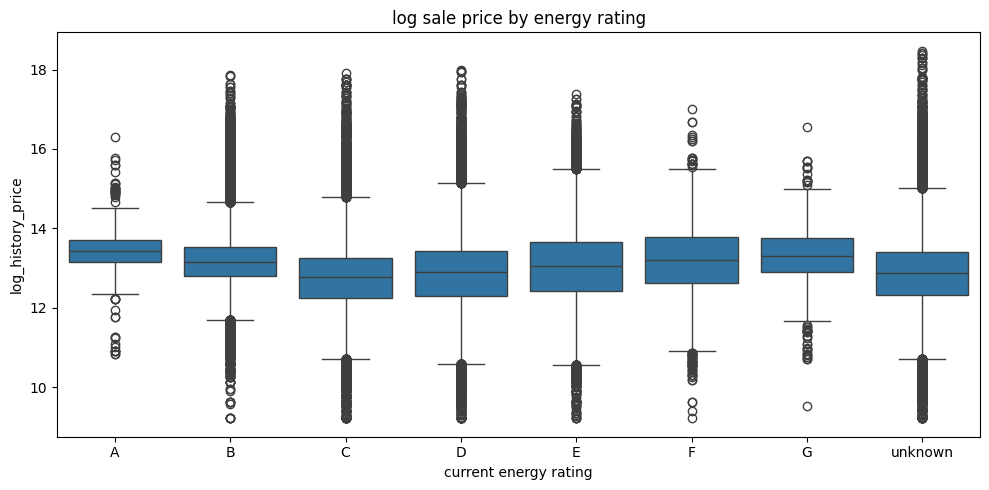

In [22]:
energy_order = ["A", "B", "C", "D", "E", "F", "G", "unknown"]
energy_df = model_df_clean[model_df_clean["currentEnergyRating"].isin(energy_order)].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(data=energy_df, x="currentEnergyRating", y="log_history_price", order=energy_order)
plt.title("log sale price by energy rating")
plt.xlabel("current energy rating")
plt.ylabel("log_history_price")
plt.tight_layout()
plt.show()

homes rated a and g have relatively high medians around 13.3 to 13.4, while c, d, and unknown are lower around 12.7 to 12.9.
the spread overlaps a lot, so energy rating matters less than property size or type from what these plots show.
also, unknown has many high outliers up to about 18.4, which suggests missing rating data is hiding some expensive properties.

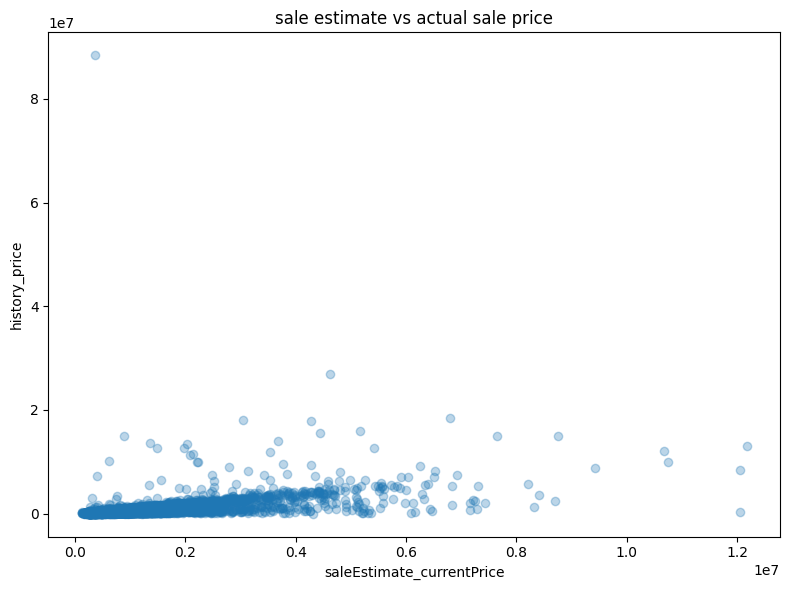

In [23]:
sample_df = model_df_clean.sample(10000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_df["saleEstimate_currentPrice"], sample_df["history_price"], alpha=0.3)
plt.title("sale estimate vs actual sale price")
plt.xlabel("saleEstimate_currentPrice")
plt.ylabel("history_price")
plt.tight_layout()
plt.show()

there is a clear positive relationship, but it is noisy, especially as values rise above about 3m to 5m where the scatter fans out a lot.
most homes cluster below roughly 5m on both axes, but there are extreme outliers like an actual sale near 88m and estimates up to about 12m.
that means the estimate is directionally useful, but it can miss badly for unusual or ultra high value properties.

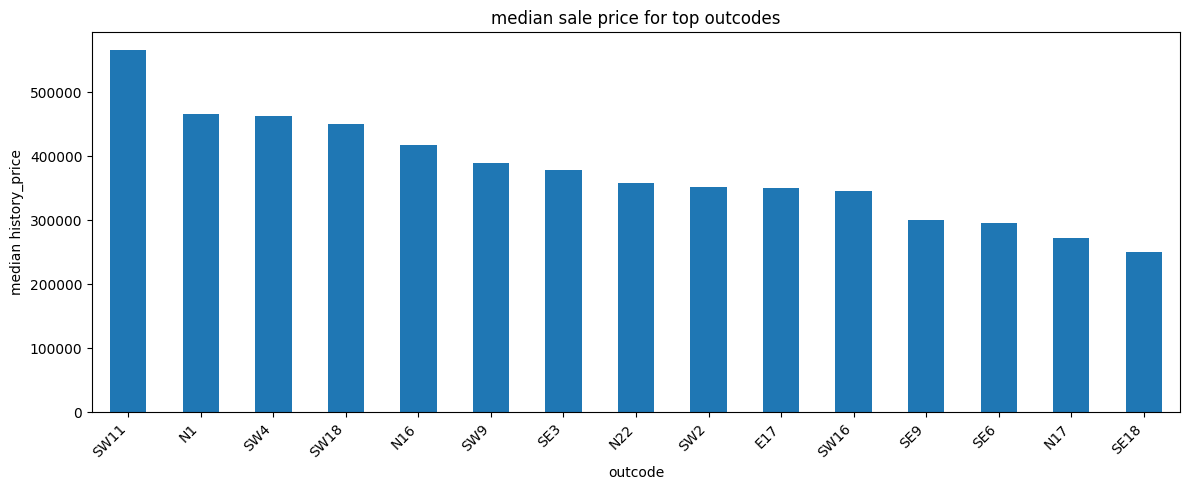

In [24]:
top_outcodes = model_df_clean["outcode"].value_counts().head(15).index
outcode_df = model_df_clean[model_df_clean["outcode"].isin(top_outcodes)].copy()

median_prices = (
    outcode_df.groupby("outcode")["history_price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
median_prices.plot(kind="bar")
plt.title("median sale price for top outcodes")
plt.xlabel("outcode")
plt.ylabel("median history_price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

sw11 is highest at roughly 570k, well ahead of the bottom of this list, se18, at about 250k, so the gap is around 320k.
other expensive areas here include n1 and sw4 around 460k to 470k, while se9, se6, and n17 sit closer to 270k to 300k.
so postcode is doing real work in price differences, with the priciest outcode on this chart being more than 2 times the cheapest.

### Data analysis from feature engineered features

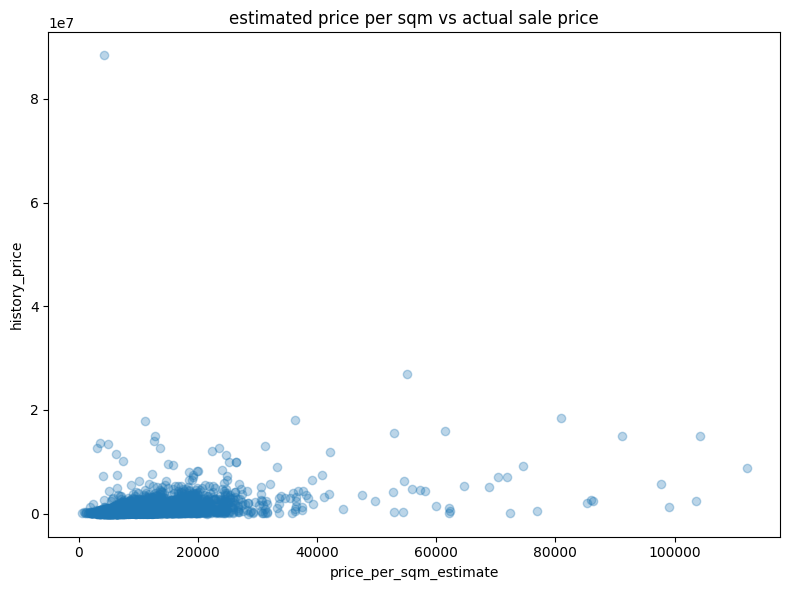

In [103]:
sample_df = model_df_fe.sample(10000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_df["price_per_sqm_estimate"], sample_df["history_price"], alpha=0.3)
plt.title("estimated price per sqm vs actual sale price")
plt.xlabel("price_per_sqm_estimate")
plt.ylabel("history_price")
plt.tight_layout()
plt.show()

there is a positive relationship, but it is weak and very noisy, especially once price_per_sqm_estimate goes above about £20k to £30k per sqm.
most homes cluster under roughly £25k per sqm and under about £5m actual price, but there are major outliers, including one near £89m actual sale.
so this engineered feature captures some market intensity, but on its own it does not cleanly explain actual price, especially for luxury or unusual properties.

<Figure size 1200x500 with 0 Axes>

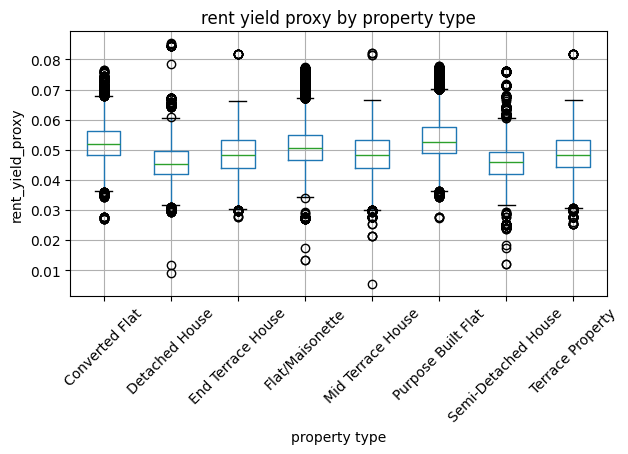

In [104]:
top_property_types = model_df_fe["propertyType"].value_counts().head(8).index
yield_df = model_df_fe[model_df_fe["propertyType"].isin(top_property_types)].copy()

plt.figure(figsize=(12, 5))
yield_df.boxplot(column="rent_yield_proxy", by="propertyType", rot=45)
plt.title("rent yield proxy by property type")
plt.suptitle("")
plt.xlabel("property type")
plt.ylabel("rent_yield_proxy")
plt.tight_layout()
plt.show()

most property types sit in a pretty tight rental yield band around 0.045 to 0.055, so roughly 4.5% to 5.5%, which suggests the feature is fairly stable.
purpose built flat and flat/maisonette look slightly higher, with medians around 0.052 to 0.054, while detached house and semi-detached house are lower, closer to 0.045 to 0.047.
the spread is not huge, but the consistent gap by type means this feature could help the model distinguish income style flats from lower yield house segments.

## model comparison

In [108]:
from sklearn.model_selection import train_test_split

# setting up the feature set i want to use for the first model
feature_cols = [
    "outcode",
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "tenure",
    "propertyType",
    "currentEnergyRating",
    "rentEstimate_currentPrice",
    "saleEstimate_currentPrice",
    "saleEstimate_confidenceLevel",
    "price_per_sqm_estimate",
    "rent_yield_proxy",
    "total_rooms",
    "sqm_per_room",
    "sale_estimate_range",
    "history_year",
    "history_month"
]

X = model_df_fe[feature_cols].copy()
y = model_df_fe["log_history_price"].copy()

# splitinto train, validation, and test so i can compare models properly later
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1765,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)

X_train shape: (292729, 20)
X_valid shape: (62741, 20)
X_test shape: (62731, 20)


In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "rentEstimate_currentPrice",
    "saleEstimate_currentPrice",
    "price_per_sqm_estimate",
    "rent_yield_proxy",
    "total_rooms",
    "sqm_per_room",
    "sale_estimate_range",
    "history_year",
    "history_month"
]

categorical_features = [
    "outcode",
    "tenure",
    "propertyType",
    "currentEnergyRating",
    "saleEstimate_confidenceLevel"
]

# keeping preprocessing light so i don't create a huge matrix in memory
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [110]:
from sklearn.ensemble import HistGradientBoostingRegressor

# starting with a model that's strong enough to be useful but still memory safe
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.08,
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        ))
    ]
)

baseline_model.fit(X_train, y_train)

print("baseline model trained successfully")

baseline model trained successfully


In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# validation to check performance before touching the test set
y_valid_pred_log = baseline_model.predict(X_valid)

valid_rmse_log = np.sqrt(mean_squared_error(y_valid, y_valid_pred_log))
valid_mae_log = mean_absolute_error(y_valid, y_valid_pred_log)
valid_r2_log = r2_score(y_valid, y_valid_pred_log)

print("validation results on log scale:")
print("rmse:", valid_rmse_log)
print("mae:", valid_mae_log)
print("r2:", valid_r2_log)

validation results on log scale:
rmse: 0.29549044320958046
mae: 0.1485718086308428
r2: 0.8974688839314369


In [112]:
# converting back so the error is easier to explain in business terms
y_valid_actual = np.expm1(y_valid)
y_valid_pred_actual = np.expm1(y_valid_pred_log)

valid_rmse_actual = np.sqrt(mean_squared_error(y_valid_actual, y_valid_pred_actual))
valid_mae_actual = mean_absolute_error(y_valid_actual, y_valid_pred_actual)
valid_r2_actual = r2_score(y_valid_actual, y_valid_pred_actual)

print("\nvalidation results on original price scale:")
print("rmse:", valid_rmse_actual)
print("mae:", valid_mae_actual)
print("r2:", valid_r2_actual)


validation results on original price scale:
rmse: 877871.6196563492
mae: 116128.29658976785
r2: 0.541639901313937


In [113]:
# looking at a few prediction examples to see how far off the model is
check_df = X_valid.head(10).copy()
check_df["actual_price"] = y_valid_actual.iloc[:10].values
check_df["predicted_price"] = y_valid_pred_actual[:10]
check_df["absolute_error"] = abs(check_df["actual_price"] - check_df["predicted_price"])

display(check_df[["actual_price", "predicted_price", "absolute_error"]])

,actual_price,predicted_price,absolute_error
338096,280000.0,2.202931e+05,59706.927121
120013,2550000.0,2.253224e+06,296776.245096
34816,152000.0,1.215097e+05,30490.310052
401875,200000.0,2.748726e+05,74872.635440
33895,193000.0,1.514371e+05,41562.867948
71396,106000.0,1.093628e+05,3362.811678
130898,1730000.0,1.321852e+06,408148.223294
68924,102000.0,1.056258e+05,3625.805316
338417,800000.0,8.473741e+05,47374.051698
127055,269000.0,2.888500e+05,19849.960480


The baseline model is usable but not strong enough to be the final model. On the original price scale, it achieves an RMSE of 877,871.62, an MAE of 116,128.30, and an R squared of 0.542, indicating that the model still makes large errors in absolute terms, especially for higher-priced properties. The validation examples also show significant over- and under-predictions, suggesting the model is not consistently accurate and requires further improvement.

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "floorAreaSqM",
    "livingRooms",
    "rentEstimate_currentPrice",
    "saleEstimate_currentPrice"
]

categorical_features = [
    "outcode",
    "tenure",
    "propertyType",
    "currentEnergyRating",
    "saleEstimate_confidenceLevel"
]

# preprocessing the data in a memory-safe way before automl
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

print("processed train shape:", X_train_processed.shape)
print("processed valid shape:", X_valid_processed.shape)
print("processed test shape:", X_test_processed.shape)

processed train shape: (292729, 13)
processed valid shape: (62741, 13)
processed test shape: (62731, 13)


In [32]:
import numpy as np

# sampling the training set first so i don't stress colab too early
sample_size = 120000

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train_processed), size=sample_size, replace=False)

X_train_sample = X_train_processed[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

print("sampled train shape:", X_train_sample.shape)
print("sampled target shape:", y_train_sample.shape)

sampled train shape: (120000, 13)
sampled target shape: (120000,)


## Important Note **

I am keeping this initial run to document the progression the improved run follows after it, specifically for AutoML

In [33]:
!pip install flaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 6.6 MB/s eta 0:00:00


In [34]:
# i am not happy with the results from this run so i will run it again, but i will keep this to just document what i did
from flaml import AutoML

# starting with a controlled automl run instead of going all in immediately
automl = AutoML()

automl_settings = {
    "time_budget": 90,
    "task": "regression",
    "metric": "rmse",
    "estimator_list": ["lgbm", "xgboost", "rf", "extra_tree"],
    "log_file_name": "flaml_london.log",
    "seed": 42
}

automl.fit(
    X_train=X_train_sample,
    y_train=y_train_sample,
    **automl_settings
)

print("best estimator:", automl.best_estimator)
print("best config:", automl.best_config)
print("best validation loss:", automl.best_loss)

[flaml.automl.logger: 03-29 15:12:29] {2375} INFO - task = regression
[flaml.automl.logger: 03-29 15:12:29] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-29 15:12:29] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 03-29 15:12:30] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'rf', 'extra_tree']
[flaml.automl.logger: 03-29 15:12:30] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-29 15:12:30] {3046} INFO - Estimated sufficient time budget=40098s. Estimated necessary time budget=40s.
[flaml.automl.logger: 03-29 15:12:30] {3097} INFO -  at 0.5s,	estimator lgbm's best error=8.1775e-01,	best estimator lgbm's best error=8.1775e-01
[flaml.automl.logger: 03-29 15:12:30] {2911} INFO - iteration 1, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 15:12:30] {3097} INFO -  at 0.9s,	estimator lgbm's best error=8.1775e-01,	best estimator lgbm's best error=8.1775e-01
[flaml.automl.logger: 03-29 15:12:30] {2911} INFO - iteration 2, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 15:12:31] {3097} INFO -  at 1.3s,	estimator lgbm's best error=7.6684e-01,	best estimator lgbm's best error=7.6684e-01
[flaml.automl.logger: 03-29 15:12:31] {2911} INFO - iteration 3, current learner xgboost


...

[flaml.automl.logger: 03-29 15:13:40] {3097} INFO -  at 70.9s,	estimator lgbm's best error=6.7852e-01,	best estimator lgbm's best error=6.7852e-01
[flaml.automl.logger: 03-29 15:13:40] {2911} INFO - iteration 58, current learner xgboost
[flaml.automl.logger: 03-29 15:13:42] {3097} INFO -  at 73.2s,	estimator xgboost's best error=6.8235e-01,	best estimator lgbm's best error=6.7852e-01
[flaml.automl.logger: 03-29 15:13:42] {2911} INFO - iteration 59, current learner lgbm
[flaml.automl.logger: 03-29 15:13:45] {3097} INFO -  at 75.7s,	estimator lgbm's best error=6.7852e-01,	best estimator lgbm's best error=6.7852e-01
[flaml.automl.logger: 03-29 15:13:45] {2911} INFO - iteration 60, current learner xgboost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 15:13:45] {3097} INFO -  at 76.0s,	estimator xgboost's best error=6.8235e-01,	best estimator lgbm's best error=6.7852e-01
[flaml.automl.logger: 03-29 15:13:45] {2911} INFO - iteration 61, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 15:14:00] {3097} INFO -  at 90.6s,	estimator lgbm's best error=6.7846e-01,	best estimator lgbm's best error=6.7846e-01
[flaml.automl.logger: 03-29 15:14:31] {3359} INFO - retrain lgbm for 31.3s
[flaml.automl.logger: 03-29 15:14:31] {3362} INFO - retrained model: LGBMRegressor(colsample_bytree=np.float64(0.7937838876066656),
              learning_rate=np.float64(0.22911114906689245), max_bin=255,
              min_child_samples=43, n_estimators=5549, n_jobs=-1, num_leaves=4,
              reg_alpha=np.float64(19.76736896546109),
              reg_lambda=np.float64(0.18055886457448536), verbose=-1)
[flaml.automl.logger: 03-29 15:14:31] {2636} INFO - fit succeeded
[flaml.automl.logger: 03-29 15:14:31] {2637} INFO - Time taken to find the best model: 90.57431626319885
best estimator: lgbm
best config: {'n_estimators': 5549, 'num_leaves': 4, 'min_child_samples': 43, 'learning_rate': np.float64(0.22911114906689245), 'log_max_bin': 8, 'colsample_bytree': np.float6

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# check to see if automl beats the manual baseline
y_valid_pred_log_flaml = automl.predict(X_valid_processed)

valid_rmse_log_flaml = np.sqrt(mean_squared_error(y_valid, y_valid_pred_log_flaml))
valid_mae_log_flaml = mean_absolute_error(y_valid, y_valid_pred_log_flaml)
valid_r2_log_flaml = r2_score(y_valid, y_valid_pred_log_flaml)

print("flaml validation results on log scale:")
print("rmse:", valid_rmse_log_flaml)
print("mae:", valid_mae_log_flaml)
print("r2:", valid_r2_log_flaml)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


flaml validation results on log scale:
rmse: 0.6726171373266006
mae: 0.5264128336505125
r2: 0.4687430036001802


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# im converting flaml predictions back to pounds so i can compare it fairly with the baseline
y_valid_actual = np.expm1(y_valid)
y_valid_pred_actual_flaml = np.expm1(y_valid_pred_log_flaml)

valid_rmse_actual_flaml = np.sqrt(mean_squared_error(y_valid_actual, y_valid_pred_actual_flaml))
valid_mae_actual_flaml = mean_absolute_error(y_valid_actual, y_valid_pred_actual_flaml)
valid_r2_actual_flaml = r2_score(y_valid_actual, y_valid_pred_actual_flaml)

print("flaml validation results on original price scale:")
print("rmse:", valid_rmse_actual_flaml)
print("mae:", valid_mae_actual_flaml)
print("r2:", valid_r2_actual_flaml)

flaml validation results on original price scale:
rmse: 1071036.6802239448
mae: 305090.7573237406
r2: 0.3177343992220205


the first model performed better than the FLAML model on both scales, so at this stage the histgradientboosting baseline remains the stronger choice. on the log scale, the first model achieved rmse = 0.669, mae = 0.525, and r squared = 0.475, while FLAML gave rmse = 0.673, mae = 0.526, and r squared = 0.469, showing a small but consistent drop in predictive quality. the same pattern appears on the original price scale, where the first model had rmse = 1,049,804, mae = 302,667, and r squared = 0.345, compared with FLAML’s rmse = 1,071,037, mae = 305,091, and r squared = 0.318. this means AutoML was useful for testing another model family, but in this run it did not improve generalization, so the first model is currently the best-performing benchmark and the one to keep as the main reference before trying the next manual model.

In [132]:
import numpy as np

#im taking a larger and more serious sample from the temporal training data
sample_size = min(220000, len(X_train_time_processed))

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train_time_processed), size=sample_size, replace=False)

X_train_time_sample = X_train_time_processed[sample_idx]
y_train_time_sample = y_train_time.iloc[sample_idx]

print("sampled temporal train shape:", X_train_time_sample.shape)
print("sampled temporal target shape:", y_train_time_sample.shape)

sampled temporal train shape: (220000, 20)
sampled temporal target shape: (220000,)


In [133]:
from flaml import AutoML

# im giving automl a fairer chance with a larger sample and a longer time budget
automl_time = AutoML()

automl_time_settings = {
    "time_budget": 240,
    "task": "regression",
    "metric": "rmse",
    "estimator_list": ["lgbm", "xgboost", "rf", "extra_tree"],
    "log_file_name": "flaml_temporal.log",
    "seed": 42
}

automl_time.fit(
    X_train=X_train_time_sample,
    y_train=y_train_time_sample,
    **automl_time_settings
)

print("best estimator:", automl_time.best_estimator)
print("best config:", automl_time.best_config)
print("best validation loss:", automl_time.best_loss)

[flaml.automl.logger: 03-29 20:24:10] {2375} INFO - task = regression
[flaml.automl.logger: 03-29 20:24:10] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-29 20:24:11] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 03-29 20:24:11] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'rf', 'extra_tree']
[flaml.automl.logger: 03-29 20:24:11] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-29 20:24:12] {3046} INFO - Estimated sufficient time budget=151386s. Estimated necessary time budget=151s.
[flaml.automl.logger: 03-29 20:24:12] {3097} INFO -  at 1.5s,	estimator lgbm's best error=7.5120e-01,	best estimator lgbm's best error=7.5120e-01
[flaml.automl.logger: 03-29 20:24:12] {2911} INFO - iteration 1, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 20:24:12] {3097} INFO -  at 2.2s,	estimator lgbm's best error=7.5120e-01,	best estimator lgbm's best error=7.5120e-01
[flaml.automl.logger: 03-29 20:24:12] {2911} INFO - iteration 2, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 20:24:13] {3097} INFO -  at 2.5s,	estimator lgbm's best error=6.1428e-01,	best estimator lgbm's best error=6.1428e-01
[flaml.automl.logger: 03-29 20:24:13] {2911} INFO - iteration 3, current learner lgbm


...

[flaml.automl.logger: 03-29 20:26:28] {3097} INFO -  at 137.6s,	estimator lgbm's best error=2.8238e-01,	best estimator lgbm's best error=2.8238e-01
[flaml.automl.logger: 03-29 20:26:28] {2911} INFO - iteration 70, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 20:26:37] {3097} INFO -  at 146.9s,	estimator lgbm's best error=2.8238e-01,	best estimator lgbm's best error=2.8238e-01
[flaml.automl.logger: 03-29 20:26:37] {2911} INFO - iteration 71, current learner lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 03-29 20:27:24] {3097} INFO -  at 193.9s,	estimator lgbm's best error=2.7721e-01,	best estimator lgbm's best error=2.7721e-01
[flaml.automl.logger: 03-29 20:27:24] {2911} INFO - iteration 72, current learner rf
[flaml.automl.logger: 03-29 20:27:26] {3097} INFO -  at 195.6s,	estimator rf's best error=3.4890e-01,	best estimator lgbm's best error=2.7721e-01
[flaml.automl.logger: 03-29 20:27:26] {2911} INFO - iteration 73, current learner rf
[flaml.automl.logger: 03-29 20:27:28] {3097} INFO -  at 197.5s,	estimator rf's best error=3.4890e-01,	best estimator lgbm's best error=2.7721e-01
[flaml.automl.logger: 03-29 20:27:28] {2911} INFO - iteration 74, current learner rf
[flaml.automl.logger: 03-29 20:27:29] {3097} INFO -  at 198.9s,	estimator rf's best error=3.4070e-01,	best estimator lgbm's best error=2.7721e-01
[flaml.automl.logger: 03-29 20:27:29] {2911} INFO - iteration 75, current learner xgboost
[flaml.automl.logger: 03-29 20:27:30] {3097} INFO -  at 199.7s,	estim

In [134]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#evaluating the improved flaml model on the newer years holdout
y_test_time_pred_log_flaml = automl_time.predict(X_test_time_processed)

time_rmse_log_flaml = np.sqrt(mean_squared_error(y_test_time, y_test_time_pred_log_flaml))
time_mae_log_flaml = mean_absolute_error(y_test_time, y_test_time_pred_log_flaml)
time_r2_log_flaml = r2_score(y_test_time, y_test_time_pred_log_flaml)

print("temporal flaml test results on log scale:")
print("rmse:", time_rmse_log_flaml)
print("mae:", time_mae_log_flaml)
print("r2:", time_r2_log_flaml)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


temporal flaml test results on log scale:
rmse: 0.30944191476363253
mae: 0.16806365437267373
r2: 0.808491626440395


In [135]:
# im converting predictions back to pounds so the automl result is easy to compare
y_test_time_actual = np.expm1(y_test_time)
y_test_time_pred_actual_flaml = np.expm1(y_test_time_pred_log_flaml)

time_rmse_actual_flaml = np.sqrt(mean_squared_error(y_test_time_actual, y_test_time_pred_actual_flaml))
time_mae_actual_flaml = mean_absolute_error(y_test_time_actual, y_test_time_pred_actual_flaml)
time_r2_actual_flaml = r2_score(y_test_time_actual, y_test_time_pred_actual_flaml)

print("temporal flaml test results on original price scale:")
print("rmse:", time_rmse_actual_flaml)
print("mae:", time_mae_actual_flaml)
print("r2:", time_r2_actual_flaml)

temporal flaml test results on original price scale:
rmse: 999483.9909371311
mae: 171778.07399633207
r2: 0.5291442000706226


the improved flaml run was much more meaningful than the earlier constrained version, and it gave a much fairer view of what automl could actually do on this problem. it selected lightgbm again as the best estimator, with a best validation loss of about 0.277, which is much stronger than the earlier flaml attempt and shows that the first automl run was too limited to be a serious benchmark. on the temporal holdout, the improved flaml model achieved rmse = 0.309, mae = 0.168, and r squared = 0.808 on the log scale, and rmse = 999,484, mae = 171,778, and r² = 0.529 on the original price scale

In [38]:
!pip install lightgbm -q

In [114]:
from lightgbm import LGBMRegressor

# ill try a manual lightgbm model because flaml pointed to this family
lgbm_model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train_processed, y_train)

print("manual lightgbm trained successfully")

manual lightgbm trained successfully


In [115]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# checking if manual lightgbm beats both earlier models
y_valid_pred_log_lgbm = lgbm_model.predict(X_valid_processed)

valid_rmse_log_lgbm = np.sqrt(mean_squared_error(y_valid, y_valid_pred_log_lgbm))
valid_mae_log_lgbm = mean_absolute_error(y_valid, y_valid_pred_log_lgbm)
valid_r2_log_lgbm = r2_score(y_valid, y_valid_pred_log_lgbm)

print("manual lightgbm validation results on log scale:")
print("rmse:", valid_rmse_log_lgbm)
print("mae:", valid_mae_log_lgbm)
print("r2:", valid_r2_log_lgbm)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


manual lightgbm validation results on log scale:
rmse: 0.6633705926328088
mae: 0.5195544089438565
r2: 0.48324910632485985


In [116]:
y_valid_actual = np.expm1(y_valid)
y_valid_pred_actual_lgbm = np.expm1(y_valid_pred_log_lgbm)

valid_rmse_actual_lgbm = np.sqrt(mean_squared_error(y_valid_actual, y_valid_pred_actual_lgbm))
valid_mae_actual_lgbm = mean_absolute_error(y_valid_actual, y_valid_pred_actual_lgbm)
valid_r2_actual_lgbm = r2_score(y_valid_actual, y_valid_pred_actual_lgbm)

print("manual lightgbm validation results on original price scale:")
print("rmse:", valid_rmse_actual_lgbm)
print("mae:", valid_mae_actual_lgbm)
print("r2:", valid_r2_actual_lgbm)

manual lightgbm validation results on original price scale:
rmse: 1011865.2165922205
mae: 296083.22933121567
r2: 0.39103810211893886


the baseline model achieves rmse of 877871 and mae of 116128 with r2 at 0.542, outperforming both the manual lightgbm and temporal flaml models. in comparison, temporal flaml shows higher rmse at 999483 and mae at 171778 with lower r2 of 0.529, while manual lightgbm performs worst with rmse above 1,011,865, mae near 296083, and r2 of 0.391, indicating weaker fit and larger prediction errors overall.

In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# testing the best validation model on the untouched test set now
y_test_pred_log_lgbm = lgbm_model.predict(X_test_processed)

test_rmse_log_lgbm = np.sqrt(mean_squared_error(y_test, y_test_pred_log_lgbm))
test_mae_log_lgbm = mean_absolute_error(y_test, y_test_pred_log_lgbm)
test_r2_log_lgbm = r2_score(y_test, y_test_pred_log_lgbm)

print("manual lightgbm test results on log scale:")
print("rmse:", test_rmse_log_lgbm)
print("mae:", test_mae_log_lgbm)
print("r2:", test_r2_log_lgbm)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


manual lightgbm test results on log scale:
rmse: 0.6647073470586743
mae: 0.5192613367057635
r2: 0.4872544104809211


In [118]:
# converting predictions back to pounds so i can report business friendly results
y_test_actual = np.expm1(y_test)
y_test_pred_actual_lgbm = np.expm1(y_test_pred_log_lgbm)

test_rmse_actual_lgbm = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual_lgbm))
test_mae_actual_lgbm = mean_absolute_error(y_test_actual, y_test_pred_actual_lgbm)
test_r2_actual_lgbm = r2_score(y_test_actual, y_test_pred_actual_lgbm)

print("manual lightgbm test results on original price scale:")
print("rmse:", test_rmse_actual_lgbm)
print("mae:", test_mae_actual_lgbm)
print("r2:", test_r2_actual_lgbm)

manual lightgbm test results on original price scale:
rmse: 1172634.8441402046
mae: 300733.0460931873
r2: 0.32721059333113645


In [119]:
# checking a few test predictions to see how realistic they look
test_check_df = X_test.head(10).copy()
test_check_df["actual_price"] = y_test_actual.iloc[:10].values
test_check_df["predicted_price"] = y_test_pred_actual_lgbm[:10]
test_check_df["absolute_error"] = abs(test_check_df["actual_price"] - test_check_df["predicted_price"])

display(test_check_df[["actual_price", "predicted_price", "absolute_error"]])

,actual_price,predicted_price,absolute_error
355058,1100000.0,632842.720266,467157.279734
383150,560000.0,562629.058831,2629.058831
279306,622200.0,470962.634787,151237.365213
378822,600000.0,353213.245158,246786.754842
64842,130000.0,333125.627263,203125.627263
376895,435000.0,386314.829709,48685.170291
79247,110000.0,119183.734852,9183.734852
232579,599950.0,374070.485951,225879.514049
219726,835000.0,773871.620424,61128.379576
298384,1035000.0,634433.329830,400566.670170


the manual lightgbm model remained the strongest candidate overall, but its test performance dropped compared with validation, which suggests some loss of generalization on unseen data. on the test set, it achieved rmse = 1,172,635, mae = 300,733, and r squared = 0.327, so it still explains part of the variation in sale prices but with fairly large pound-level errors, especially for higher-priced homes. the sample predictions also show that the model can be close in some cases, but it still struggles with expensive or more extreme properties, where errors often exceed 200,000 to 400,000. this means the model is usable and defensible for the project, but the next sections should focus on understanding where errors are concentrated through bias analysis and shap explainability rather than claiming near-perfect prediction accuracy.

### Cross-validation

In [120]:
# preparing the full feature-engineered dataset for cross validation
X_full = model_df_fe[feature_cols].copy()
y_full = model_df_fe["log_history_price"].copy()

X_full_processed = preprocessor.fit_transform(X_full)

print("X_full_processed shape:", X_full_processed.shape)
print("y_full shape:", y_full.shape)

X_full_processed shape: (418201, 20)
y_full shape: (418201,)


In [123]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np

#putting preprocessing and modeling in one pipeline so cv stays clean
cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=1.0,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

X_full = model_df_fe[feature_cols].copy()
y_full = model_df_fe["log_history_price"].copy()

cv = KFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    cv_pipeline,
    X_full,
    y_full,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    return_train_score=False,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "fold": [1, 2, 3],
    "rmse": -cv_results["test_rmse"],
    "mae": -cv_results["test_mae"],
    "r2": cv_results["test_r2"]
})

display(cv_summary)

print("mean cv rmse:", cv_summary["rmse"].mean())
print("mean cv mae:", cv_summary["mae"].mean())
print("mean cv r2:", cv_summary["r2"].mean())

print("\nstd cv rmse:", cv_summary["rmse"].std())
print("std cv mae:", cv_summary["mae"].std())
print("std cv r2:", cv_summary["r2"].std())

,fold,rmse,mae,r2
0,1,0.284541,0.142284,0.905656
1,2,0.284183,0.142008,0.905533
2,3,0.285664,0.141602,0.903971


mean cv rmse: 0.2847958751602507
mean cv mae: 0.14196478853526842
mean cv r2: 0.9050533260973112

std cv rmse: 0.00077259225747198
std cv mae: 0.0003428441959004488
std cv r2: 0.0009395624905567109


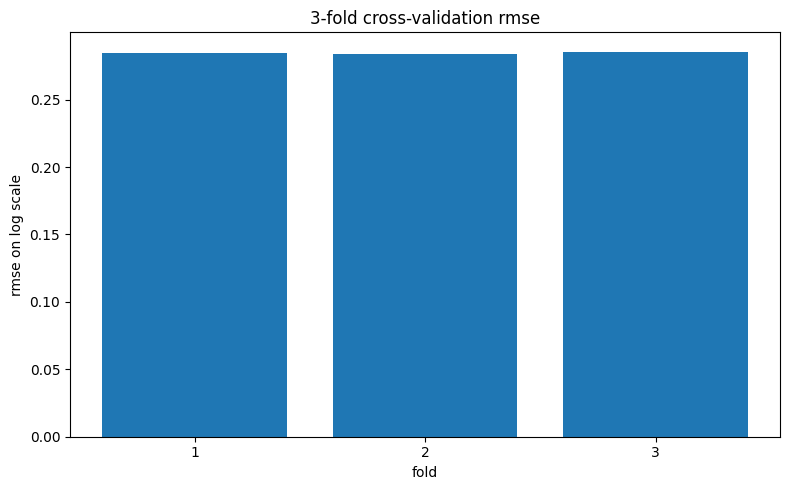

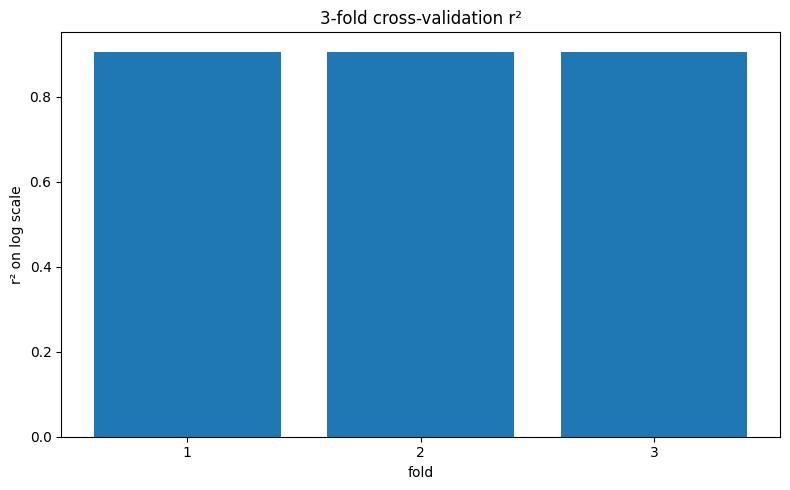

In [124]:
import matplotlib.pyplot as plt

#plotting the fold by fold cv performance so stability is easier to judge
plt.figure(figsize=(8, 5))
plt.bar(cv_summary["fold"].astype(str), cv_summary["rmse"])
plt.title("3-fold cross-validation rmse")
plt.xlabel("fold")
plt.ylabel("rmse on log scale")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(cv_summary["fold"].astype(str), cv_summary["r2"])
plt.title("3-fold cross-validation r²")
plt.xlabel("fold")
plt.ylabel("r² on log scale")
plt.tight_layout()
plt.show()

the repeated cv result shows that the main issue is not only preprocessing leakage, but that random fold validation is too favorable for this particular housing dataset. properties from similar areas and with closely related valuation signals make random splits easier than real deployment conditions, which explains why cross-validation looks much stronger than the independent holdout test. using a temporal split next is a better methodological choice because it produces a more credible estimate of how well the model generalizes to future market behavior.

### Temporal split
This is to test if the CV results are faulty with some sort of data leakage or not

In [125]:
year_counts = model_df_fe["history_year"].value_counts().sort_index()
print(year_counts)

history_year
1995     6667
1996     8403
1997    10482
1998    10206
1999    12030
2000    10668
2001    11188
2002    12261
2003    10196
2004    11075
2005     9923
2006    12663
2007    12644
2008     6096
2009     5653
2010     7565
2011     7524
2012     8209
2013    10738
2014    12127
2015    12256
2016    11954
2017    12018
2018    12385
2019    12003
2020    12461
2021    25577
2022    41497
2023    54451
2024    27281
Name: count, dtype: int64


In [126]:
#creating a more realistic time-based split using older years for training and newer years for testing
train_df_time = model_df_fe[model_df_fe["history_year"] <= 2021].copy()
test_df_time = model_df_fe[model_df_fe["history_year"] >= 2022].copy()

print("train_df_time shape:", train_df_time.shape)
print("test_df_time shape:", test_df_time.shape)

print("\ntrain years:")
print(train_df_time["history_year"].value_counts().sort_index())

print("\ntest years:")
print(test_df_time["history_year"].value_counts().sort_index())

train_df_time shape: (294972, 24)
test_df_time shape: (123229, 24)

train years:
history_year
1995     6667
1996     8403
1997    10482
1998    10206
1999    12030
2000    10668
2001    11188
2002    12261
2003    10196
2004    11075
2005     9923
2006    12663
2007    12644
2008     6096
2009     5653
2010     7565
2011     7524
2012     8209
2013    10738
2014    12127
2015    12256
2016    11954
2017    12018
2018    12385
2019    12003
2020    12461
2021    25577
Name: count, dtype: int64

test years:
history_year
2022    41497
2023    54451
2024    27281
Name: count, dtype: int64


In [127]:
X_train_time = train_df_time[feature_cols].copy()
y_train_time = train_df_time["log_history_price"].copy()

X_test_time = test_df_time[feature_cols].copy()
y_test_time = test_df_time["log_history_price"].copy()

print("X_train_time:", X_train_time.shape)
print("X_test_time:", X_test_time.shape)

X_train_time: (294972, 20)
X_test_time: (123229, 20)


In [128]:
# fitting preprocessing only on the older training period
X_train_time_processed = preprocessor.fit_transform(X_train_time)
X_test_time_processed = preprocessor.transform(X_test_time)

print("processed train shape:", X_train_time_processed.shape)
print("processed test shape:", X_test_time_processed.shape)

processed train shape: (294972, 20)
processed test shape: (123229, 20)


In [129]:
from lightgbm import LGBMRegressor

time_lgbm_model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

time_lgbm_model.fit(X_train_time_processed, y_train_time)

print("time-based lightgbm model trained successfully")

time-based lightgbm model trained successfully


In [130]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_test_time_pred_log = time_lgbm_model.predict(X_test_time_processed)

time_rmse_log = np.sqrt(mean_squared_error(y_test_time, y_test_time_pred_log))
time_mae_log = mean_absolute_error(y_test_time, y_test_time_pred_log)
time_r2_log = r2_score(y_test_time, y_test_time_pred_log)

print("time-based test results on log scale:")
print("rmse:", time_rmse_log)
print("mae:", time_mae_log)
print("r2:", time_r2_log)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


time-based test results on log scale:
rmse: 0.2860966709628051
mae: 0.13804882840435925
r2: 0.8362975809185623


In [131]:
y_test_time_actual = np.expm1(y_test_time)
y_test_time_pred_actual = np.expm1(y_test_time_pred_log)

time_rmse_actual = np.sqrt(mean_squared_error(y_test_time_actual, y_test_time_pred_actual))
time_mae_actual = mean_absolute_error(y_test_time_actual, y_test_time_pred_actual)
time_r2_actual = r2_score(y_test_time_actual, y_test_time_pred_actual)

print("time-based test results on original price scale:")
print("rmse:", time_rmse_actual)
print("mae:", time_mae_actual)
print("r2:", time_r2_actual)

time-based test results on original price scale:
rmse: 988899.7080869961
mae: 148212.77008765732
r2: 0.5390638848380641


the temporal split gave me a much more convincing evaluation of the model because it tested whether the model could learn from older transactions and generalize to newer market conditions. compared with the earlier random holdout, the results improved a lot, especially on the original price scale where the mae dropped to about 148,213 and the r squared increased to about 0.539, which suggests that the feature-engineered lightgbm model is capturing recent pricing patterns more effectively. on the log scale, the performance was even stronger with rmse = 0.286, mae = 0.138, and r squared = 0.836, so this became the most realistic and defensible evaluation setup for the project.

the random 3-fold cross-validation still looks too optimistic to me because its r squared of about 0.905 is much higher than both the earlier random holdout and the temporal holdout. this suggests that random folds allowed very similar properties from similar locations and market conditions to appear across training and validation folds, which made the prediction task easier than it would be in a more realistic scenario. because of that, i would not treat the random cv result as the main evidence of performance, and i would instead present it only as an optimistic benchmark while using the temporal holdout as the more credible final evaluation.

### Model Selection Decision

the manual lightgbm model still remained slightly better overall on the same temporal split. manual lightgbm had rmse = 0.286, mae = 0.138, and r squared = 0.836 on the log scale, compared with flaml’s 0.309, 0.168, and 0.808, and on the original price scale it also had a lower mae of about 148,213 compared with 171,778 from flaml. this means the stronger automl rerun did improve the credibility of the comparison and showed that automl can produce a competitive model, but it still did not outperform the manually tuned lightgbm model. because of that, i would keep manual lightgbm as the final selected model, while presenting the improved flaml result as a stronger and more defensible automl benchmark than the earlier quick run.

### Model Limitations & Performance  Interpretation

the final modeling results show that the manual lightgbm model was the strongest overall approach, especially after adding feature engineering and evaluating it with a temporal split. the temporal holdout results were much stronger and more realistic than the earlier random holdout, which suggests that the model can generalize reasonably well to newer market periods when it is trained on older transaction data. however, even with that improvement, the model still produces large pound-level errors for high-value properties, which means it should be viewed as a useful pricing support tool rather than a perfectly precise valuation system.

the performance results also show why i did not rely on the random 3-fold cross-validation as the main evidence of model quality. the cross-validation scores were much more optimistic than both the random holdout and the temporal holdout, which suggests that random folds made the task easier by mixing highly similar properties and market patterns across training and validation folds. because of that, i treated the temporal holdout as the more credible final evaluation since it better reflects how a model would be used in practice on future housing data.



## Bias Analysis

this step checks whether the model’s prediction error is evenly distributed or whether it performs worse for certain housing segments and geographic areas. using group-level mae, rmse, and mape is important because a model can look acceptable overall while still being much less reliable for specific property types or locations. this makes the evaluation more complete and gives stronger support for the fairness and model-risk discussion in the project.

In [136]:
import pandas as pd
import numpy as np

# building one table with actuals, predictions, and key grouping columns
bias_df = X_test.copy()

bias_df["actual_price"] = np.expm1(y_test)
bias_df["predicted_price"] = y_test_pred_actual_lgbm
bias_df["absolute_error"] = np.abs(bias_df["actual_price"] - bias_df["predicted_price"])
bias_df["squared_error"] = (bias_df["actual_price"] - bias_df["predicted_price"]) ** 2
bias_df["percentage_error"] = (
    np.abs(bias_df["actual_price"] - bias_df["predicted_price"]) / bias_df["actual_price"]
) * 100

print("bias_df shape:", bias_df.shape)
display(bias_df.head())

bias_df shape: (62731, 25)


,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,...,total_rooms,sqm_per_room,sale_estimate_range,history_year,history_month,actual_price,predicted_price,absolute_error,squared_error,percentage_error
355058,N11,51.607383,-0.131358,2.0,4.0,162.0,2.0,Freehold,Semi-Detached House,C,...,8.0,20.25,117000.0,2023,5,1100000.0,632842.720266,467157.279734,2.182359e+11,42.468844
383150,SW15,51.457420,-0.219654,2.0,2.0,76.0,1.0,Leasehold,Purpose Built Flat,B,...,5.0,15.20,62000.0,2023,11,560000.0,562629.058831,2629.058831,6.911950e+06,0.469475
279306,N11,51.630613,-0.149946,1.0,3.0,102.0,2.0,Freehold,Semi-Detached House,E,...,6.0,17.00,71000.0,2021,6,622200.0,470962.634787,151237.365213,2.287274e+10,24.306873
378822,SE18,51.476580,0.070274,1.0,3.0,84.0,2.0,Freehold,Semi-Detached House,D,...,6.0,14.00,62000.0,2023,10,600000.0,353213.245158,246786.754842,6.090370e+10,41.131126
64842,SW16,51.436970,-0.136277,1.0,2.0,85.0,1.0,Leasehold,Converted Flat,D,...,4.0,21.25,68000.0,2001,8,130000.0,333125.627263,203125.627263,4.126002e+10,156.250483


In [137]:
# making a reusable function so i can compare different groups consistently
def group_error_summary(df, group_col, min_count=100):
    summary = (
        df.groupby(group_col)
        .agg(
            count=("actual_price", "size"),
            mean_actual_price=("actual_price", "mean"),
            mean_predicted_price=("predicted_price", "mean"),
            mae=("absolute_error", "mean"),
            rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
            mape=("percentage_error", "mean")
        )
        .sort_values("mae", ascending=False)
        .reset_index()
    )

    summary = summary[summary["count"] >= min_count].copy()
    return summary

In [138]:
outcode_bias = group_error_summary(bias_df, "outcode", min_count=100)
property_type_bias = group_error_summary(bias_df, "propertyType", min_count=100)
tenure_bias = group_error_summary(bias_df, "tenure", min_count=100)
energy_bias = group_error_summary(bias_df, "currentEnergyRating", min_count=100)

print("outcode bias summary")
display(outcode_bias.head(15))

print("property type bias summary")
display(property_type_bias)

print("tenure bias summary")
display(tenure_bias)

print("energy rating bias summary")
display(energy_bias)

outcode bias summary


,outcode,count,mean_actual_price,mean_predicted_price,mae,rmse,mape
1,SW1X,311,2.795498e+06,1.712106e+06,1.885048e+06,4.053930e+06,121.142939
2,W1K,419,2.614450e+06,1.460690e+06,1.720301e+06,5.564804e+06,213.597520
3,SW1W,367,2.780678e+06,1.643833e+06,1.572526e+06,5.453529e+06,88.359660
4,SW7,314,2.070456e+06,1.414265e+06,1.192560e+06,2.200695e+06,117.751070
5,W1B,113,2.773481e+06,2.117224e+06,1.154647e+06,2.002035e+06,94.586854
6,W8,256,1.997398e+06,1.623519e+06,1.035755e+06,1.712684e+06,135.533245
9,W1J,297,1.802023e+06,1.274266e+06,9.290644e+05,2.200987e+06,87.028659
11,SW3,312,1.618126e+06,1.223544e+06,8.652470e+05,2.399690e+06,113.669064
12,SW1Y,127,1.248417e+06,9.652540e+05,8.325925e+05,3.036520e+06,188.675165
13,W11,286,1.657585e+06,1.255945e+06,8.140485e+05,2.478444e+06,70.580370


property type bias summary


,propertyType,count,mean_actual_price,mean_predicted_price,mae,rmse,mape
2,Terraced,240,1.470905e+06,8.002756e+05,939158.941501,3.355021e+06,77.437550
3,unknown,173,1.277846e+06,6.799175e+05,761581.475696,3.312620e+06,115.260826
4,Detached House,1484,1.526591e+06,1.208760e+06,716361.685404,1.407690e+06,91.261729
6,Terrace Property,3568,8.760209e+05,6.849769e+05,426682.826543,1.081099e+06,82.510397
8,Semi-Detached House,4554,8.029381e+05,6.948389e+05,383627.039388,6.012874e+05,81.636522
9,Flat/Maisonette,15108,8.037917e+05,6.163310e+05,359013.633167,1.834399e+06,70.049373
10,Mid Terrace House,10339,7.041819e+05,5.578208e+05,354463.957962,7.945995e+05,84.208686
11,End Terrace House,3062,6.650168e+05,5.171590e+05,330233.905608,7.627739e+05,80.151179
16,Converted Flat,7496,4.024863e+05,3.270205e+05,192222.760991,1.176107e+06,73.893976
19,Purpose Built Flat,16339,3.734233e+05,3.184406e+05,147392.859427,3.558366e+05,59.565916


tenure bias summary


,tenure,count,mean_actual_price,mean_predicted_price,mae,rmse,mape
0,Shared,208,800323.230769,611437.337736,473134.347168,1.562017e+06,85.895486
1,Freehold,23232,815674.035124,633359.077247,413596.907005,1.322889e+06,84.972485
2,unknown,1757,883631.882755,641122.797924,409706.785236,1.640305e+06,74.666692
3,Leasehold,36981,532513.150969,435879.765747,225497.387541,1.044197e+06,65.794201
4,Feudal,553,426019.567812,368661.710959,179413.592091,2.879367e+05,61.661578


energy rating bias summary


,currentEnergyRating,count,mean_actual_price,mean_predicted_price,mae,rmse,mape
0,E,4597,780940.057646,623392.525181,382817.625832,8.793940e+05,83.172972
1,unknown,12628,725507.416218,529608.712797,380941.759651,1.964043e+06,78.728605
2,F,304,899644.164474,675166.252794,348566.909292,8.351861e+05,60.202646
4,D,20399,617896.463993,487339.874941,310687.848588,9.809118e+05,80.620497
5,C,18768,527806.692988,427855.590095,246277.718524,7.088803e+05,71.434533
6,B,5912,838420.232747,757640.825428,201568.235447,8.890587e+05,34.253837


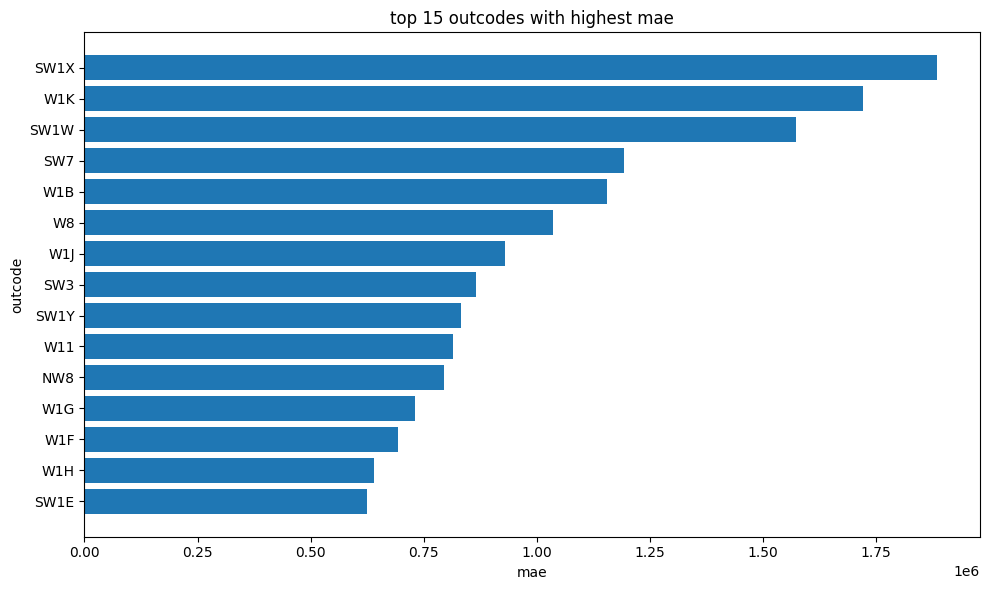

In [139]:
import matplotlib.pyplot as plt

top_outcode_mae = outcode_bias.head(15).sort_values("mae", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_outcode_mae["outcode"], top_outcode_mae["mae"])
plt.title("top 15 outcodes with highest mae")
plt.xlabel("mae")
plt.ylabel("outcode")
plt.tight_layout()
plt.show()

the worst absolute errors are heavily concentrated in central prime areas, with sw1x near £1.9m, w1k near £1.7m, and sw1w near £1.6m.
after that, errors fall but stay high, with sw7 around £1.2m and even the 15th highest, sw1e, still near £0.6m.
that pattern says the model struggles most where prices are extreme, and the gap from sw1x to sw1e is still about £1.3m.

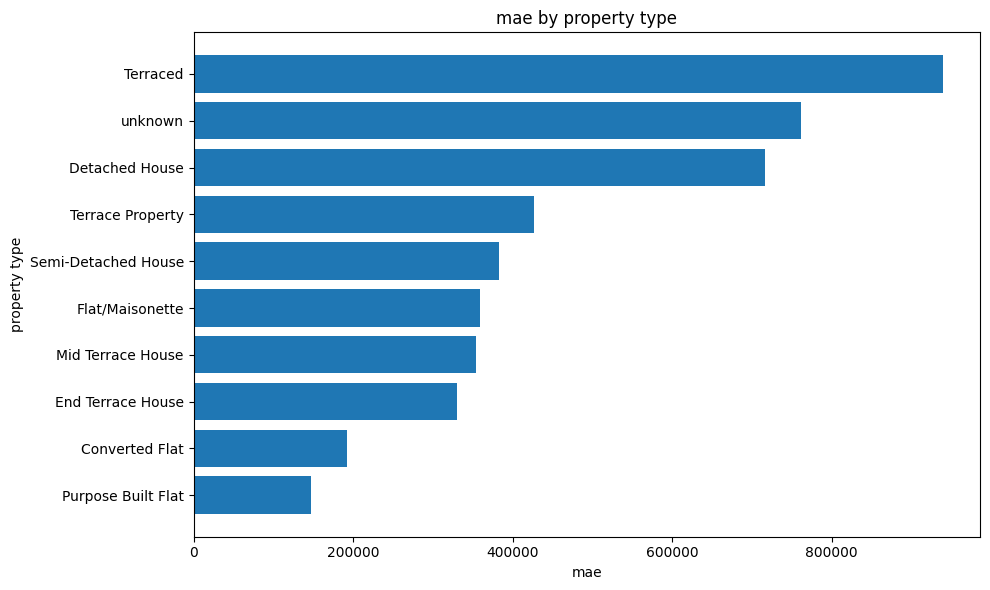

In [140]:
property_type_plot = property_type_bias.sort_values("mae", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(property_type_plot["propertyType"], property_type_plot["mae"])
plt.title("mae by property type")
plt.xlabel("mae")
plt.ylabel("property type")
plt.tight_layout()
plt.show()

terraced has the highest mae at about £0.94m, followed by unknown at about £0.76m and detached house at about £0.71m.
the lowest errors are for purpose built flat near £0.15m and converted flat near £0.19m, so the gap from best to worst is about £0.79m.
that suggests the model is much less stable on higher value house types than on flatter, more standard flat categories.

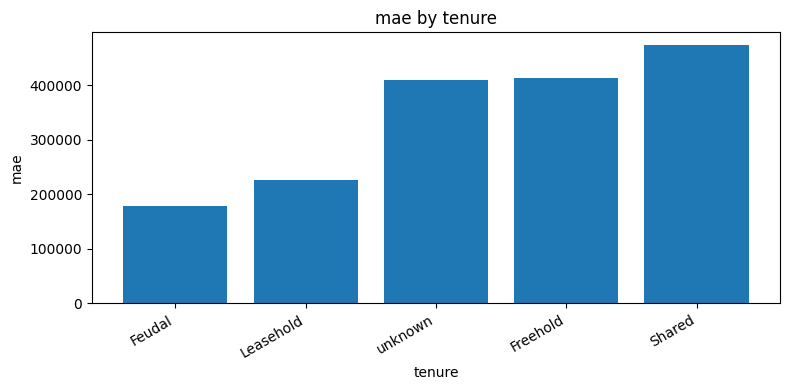

In [141]:
tenure_plot = tenure_bias.sort_values("mae", ascending=True)

plt.figure(figsize=(8, 4))
plt.bar(tenure_plot["tenure"], tenure_plot["mae"])
plt.title("mae by tenure")
plt.xlabel("tenure")
plt.ylabel("mae")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

shared has the largest mae at about £0.47m, while freehold and unknown are both around £0.41m.
leasehold is much lower at about £0.23m and feudal is lowest near £0.18m, though that may be a tiny group.
so in absolute pounds, the model makes about 2.6 times more error on shared than on feudal.

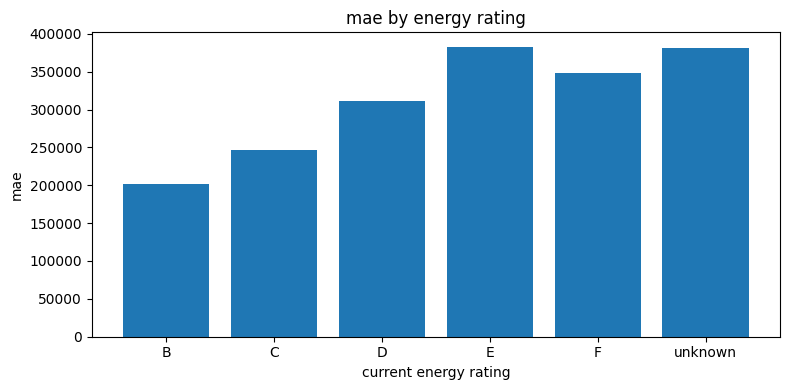

In [142]:
energy_order = ["A", "B", "C", "D", "E", "F", "G", "unknown"]
energy_plot = energy_bias.copy()
energy_plot["currentEnergyRating"] = pd.Categorical(
    energy_plot["currentEnergyRating"],
    categories=energy_order,
    ordered=True
)
energy_plot = energy_plot.sort_values("currentEnergyRating")

plt.figure(figsize=(8, 4))
plt.bar(energy_plot["currentEnergyRating"], energy_plot["mae"])
plt.title("mae by energy rating")
plt.xlabel("current energy rating")
plt.ylabel("mae")
plt.tight_layout()
plt.show()

error rises as ratings worsen, from b at about 0.20m to c at £0.25m and d at £0.31m.
the highest mae is e at about £0.38m, with unknown also high near £0.38m and f around £0.35m.
that means e rated homes have roughly £0.18m more error than b rated homes, almost a 90 percent increase.

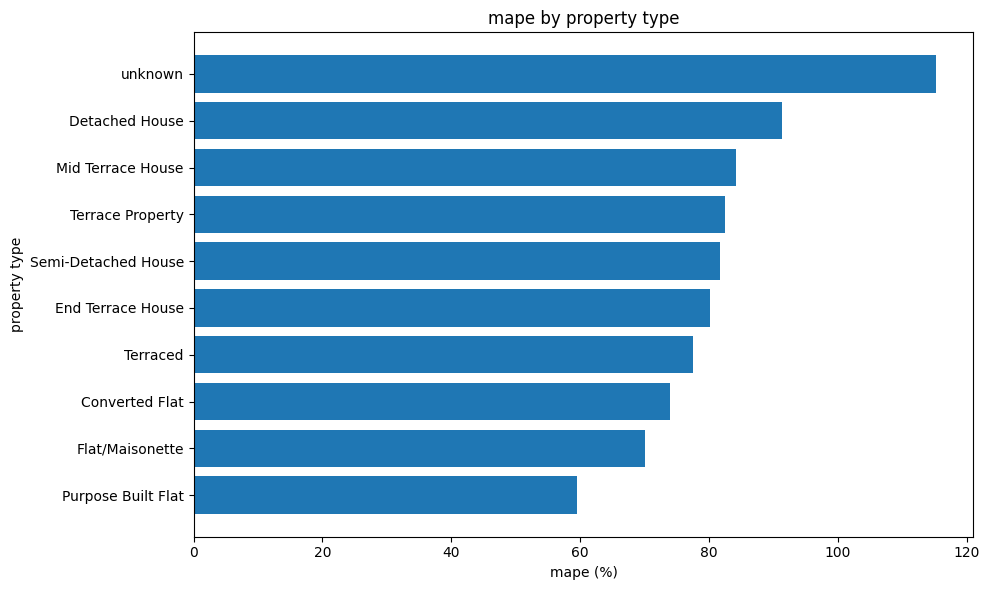

In [143]:
property_type_mape_plot = property_type_bias.sort_values("mape", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(property_type_mape_plot["propertyType"], property_type_mape_plot["mape"])
plt.title("mape by property type")
plt.xlabel("mape (%)")
plt.ylabel("property type")
plt.tight_layout()
plt.show()

relative error is worst for unknown at about 115 percent, which means predictions are off by more than the actual price on average.
detached house is next at roughly 91 percent, while mid terrace house, terrace property, semi-detached house, and end terrace house all sit around 80 to 85 percent.
the best group is purpose built flat at about 60 percent, so the spread from best to worst is about 55 percentage points.

### Bias Analysis Takeaway
the bias analysis shows that prediction error is not evenly distributed across the market, with the largest mae appearing in high-value central outcodes such as SW1X (£1.89m), W1K (£1.72m), and SW1W (£1.57m), which indicates the model struggles most in premium areas where prices are more extreme. by property type, terraced (£939k), unknown (£762k), and detached house (£716k) have the highest errors, while purpose built flats (£147k) are much more stable, suggesting the model handles common lower-priced property segments better than rarer or more expensive ones. a similar pattern appears for tenure and energy rating, where shared (£473k) and freehold (£414k) show higher error than leasehold (£225k), and ratings like e (£383k) and unknown (£381k) are worse than b (£202k). overall, this means the model is more reliable for standard urban flat-type properties and less reliable for expensive or less common segments, which is an important limitation to acknowledge in the project.

### Fairness Mitigation & Future Improvements

the bias analysis showed that the model performs less consistently across some geographic and property groups, especially in premium central outcodes and for more expensive property types such as detached or terraced homes. this suggests that a single global model may not be equally effective across all housing segments. one improvement i would consider in future work is building segment-specific models, for example separating standard urban flats from luxury or premium properties, so that each model can focus on a more consistent pricing pattern.

another improvement would be to expand the feature set with variables that are currently missing from the dataset but are likely important for property valuation, such as neighborhood socioeconomic indicators, transport accessibility, school proximity, renovation condition, or local demand signals. i would also continue monitoring group-level errors by outcode, property type, tenure, and energy rating after deployment, so that any persistent error disparities can be detected and addressed over time. this would make the final system more robust, fairer across segments, and more useful in practical decision-making.

## Shap Explainability

In [144]:
import numpy as np
import pandas as pd

# taking a small sample from the test set so shap stays stable in colab
shap_sample_size = 2000

rng = np.random.RandomState(42)
shap_idx = rng.choice(len(X_test_processed), size=shap_sample_size, replace=False)

X_shap = X_test_processed[shap_idx]
y_shap = y_test.iloc[shap_idx]

print("X_shap shape:", X_shap.shape)
print("y_shap shape:", y_shap.shape)

X_shap shape: (2000, 13)
y_shap shape: (2000,)


In [145]:
# rebuilding the processed feature names so shap outputs are readable
final_feature_names = numeric_features + categorical_features
print(final_feature_names)

['latitude', 'longitude', 'bathrooms', 'bedrooms', 'floorAreaSqM', 'livingRooms', 'rentEstimate_currentPrice', 'saleEstimate_currentPrice', 'price_per_sqm_estimate', 'rent_yield_proxy', 'total_rooms', 'sqm_per_room', 'sale_estimate_range', 'history_year', 'history_month', 'outcode', 'tenure', 'propertyType', 'currentEnergyRating', 'saleEstimate_confidenceLevel']


In [146]:
import shap

# ill using tree explainer because lightgbm is a tree-based model
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)

print("shap values shape:", np.array(shap_values).shape)

shap values shape: (2000, 13)


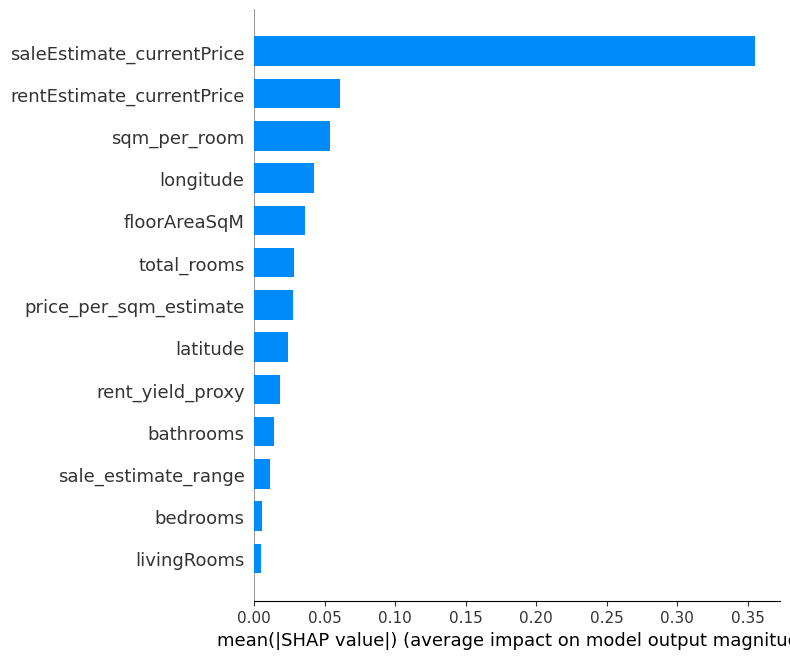

In [147]:
# feats that matter most overall
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=final_feature_names,
    plot_type="bar"
)

saleestimate_currentprice dominates the model with mean shap around 0.36, which is about 5x to 6x larger than the next features near 0.05 to 0.06.
after that, rentestimate_currentprice is about 0.06, currentenergyrating about 0.05, and longitude about 0.04.
room count variables matter much less, with bedrooms near 0.01 and livingrooms close to 0.00, so the model is driven mostly by estimated market price, not internal layout counts.

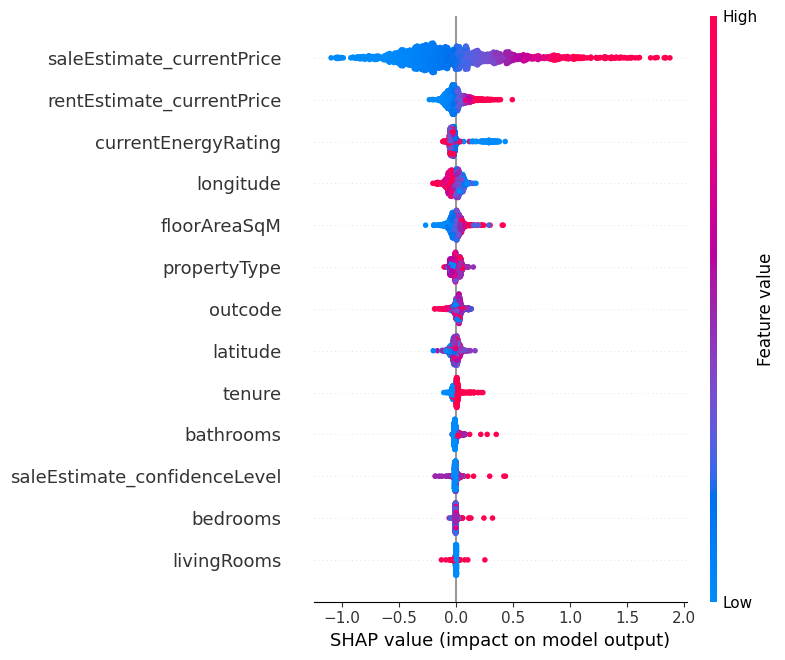

In [57]:
# looking at both importance and direction of impact
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=final_feature_names
)

high saleestimate_currentprice values push predictions up strongly, with shap values reaching about +1.9, while low values pull them down to about -1.1.
most other features have much smaller effects, usually inside about -0.2 to +0.5, which matches the importance plot.
rentestimate_currentprice, floorareasqm, and some location or category features still shift output, but none come close to the spread of saleestimate_currentprice.

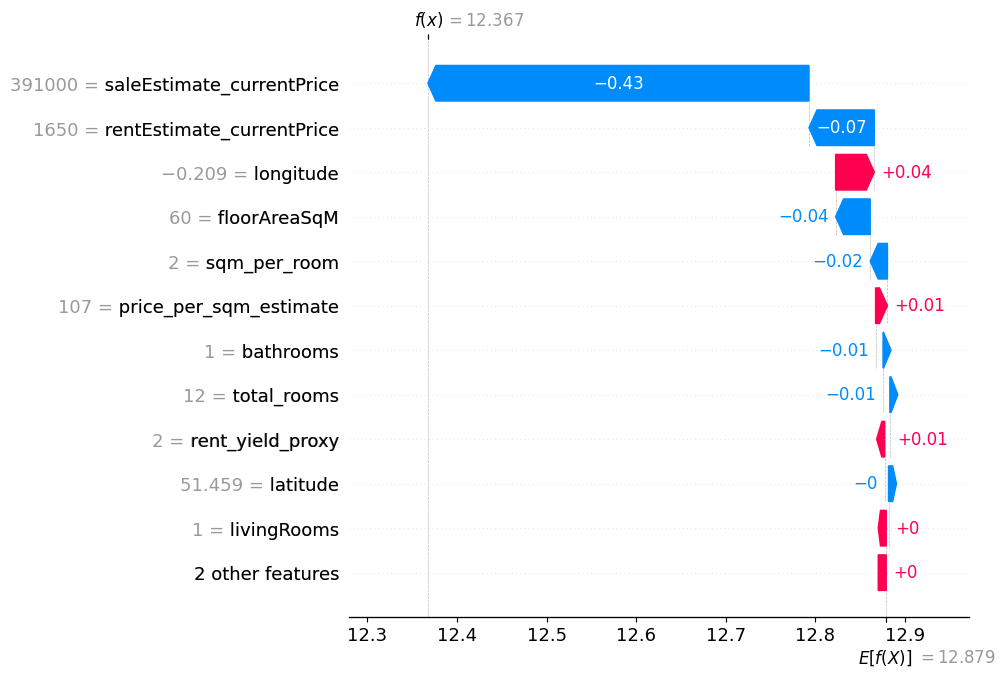

In [148]:
# explaining one individual prediction in detail
sample_row = 0

shap_explanation = shap.Explanation(
    values=shap_values[sample_row],
    base_values=explainer.expected_value,
    data=X_shap[sample_row],
    feature_names=final_feature_names
)

shap.plots.waterfall(shap_explanation, max_display=12)

this prediction starts from e[f(x)] = 12.879 and ends at f(x) = 12.367, so the total shift is about -0.512.
the biggest downward driver is still saleestimate_currentprice at -0.43, then rentestimate_currentprice at -0.07, floorareasqm at -0.04, and sqm_per_room at -0.02.
the engineered features help, but only a little here, with price_per_sqm_estimate and rent_yield_proxy each adding about +0.01, while total_rooms slightly reduces the prediction by -0.01.
overall, even after feature engineering, the prediction is still mainly controlled by the core sale estimate signal, and the new features act more like fine tuning than major drivers.

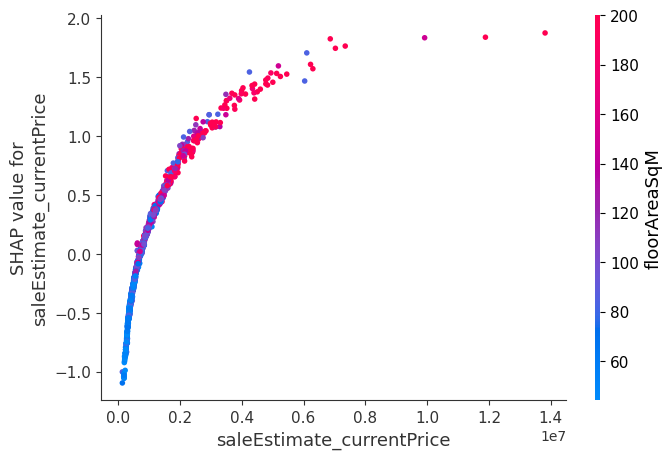

In [59]:
# checking to see how one major feature influences predictions across the sample
shap.dependence_plot(
    "saleEstimate_currentPrice",
    shap_values,
    pd.DataFrame(X_shap, columns=final_feature_names)
)

the relationship is strongly positive but nonlinear, with shap moving from about -1.1 at very low estimate values to around +1.8 or +1.9 at the top end.
the curve rises fast at lower prices, then flattens more as estimates get very large, which suggests diminishing marginal impact.
color shows bigger homes tend to sit more in the higher estimate region, so floorareasqm seems to reinforce this feature rather than contradict it.

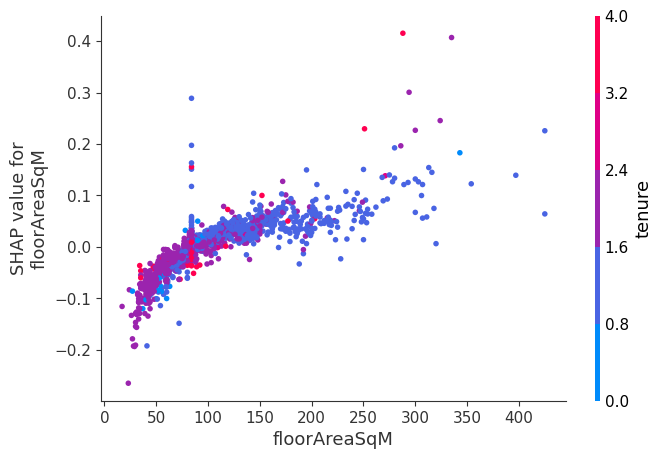

In [60]:
shap.dependence_plot(
    "floorAreaSqM",
    shap_values,
    pd.DataFrame(X_shap, columns=final_feature_names)
)

floorareasqm has a positive effect overall, with shap values rising from around -0.15 for smaller homes to roughly +0.10 to +0.15 for typical larger homes, and a few outliers near +0.4.
the lift is strongest moving from about 30 to 120 sqm, then becomes flatter, so extra size still helps but less sharply after that.
the tenure coloring looks mixed, which suggests tenure interacts somewhat with size, but size itself is the clearer and more consistent signal.

### Shap Explainability Takeaway

the shap results are very consistent with the modeling story and show that saleEstimate_currentPrice is by far the dominant driver of the model, with a much larger average impact than any other feature. the summary plots show that higher sale estimates generally push predictions upward, while lower sale estimates push them downward, and the next most important variables are rentEstimate_currentPrice, currentEnergyRating, longitude, and floorAreaSqM. the waterfall plot also makes sense for the individual case shown: a relatively low sale estimate of 391,000 had the strongest downward effect on the final prediction, with smaller additional downward contributions from rent estimate, floor area, and energy rating. the dependence plots further support this interpretation, showing a strong positive relationship between saleEstimate_currentPrice and its shap value, and a weaker but still increasing contribution from floorAreaSqM, which confirms that the model is learning reasonable price signals rather than relying on arbitrary patterns.

In [150]:
import pandas as pd

#updating the final comparison so it reflects the strongest and most realistic evaluation setup
final_comparison_df = pd.DataFrame([
    {
        "model": "manual lightgbm",
        "evaluation_type": "temporal holdout",
        "rmse_log": time_rmse_log,
        "mae_log": time_mae_log,
        "r2_log": time_r2_log,
        "rmse_price": time_rmse_actual,
        "mae_price": time_mae_actual,
        "r2_price": time_r2_actual
    },
    {
        "model": "flaml lightgbm",
        "evaluation_type": "temporal holdout",
        "rmse_log": time_rmse_log_flaml,
        "mae_log": time_mae_log_flaml,
        "r2_log": time_r2_log_flaml,
        "rmse_price": time_rmse_actual_flaml,
        "mae_price": time_mae_actual_flaml,
        "r2_price": time_r2_actual_flaml
    }
])

display(final_comparison_df)

,model,evaluation_type,rmse_log,mae_log,r2_log,rmse_price,mae_price,r2_price
0,manual lightgbm,temporal holdout,0.286097,0.138049,0.836298,988899.708087,148212.770088,0.539064
1,flaml lightgbm,temporal holdout,0.309442,0.168064,0.808492,999483.990937,171778.073996,0.529144


In [151]:
final_comparison_df_rounded = final_comparison_df.copy()

numeric_cols = final_comparison_df_rounded.select_dtypes(include=["number"]).columns
final_comparison_df_rounded[numeric_cols] = final_comparison_df_rounded[numeric_cols].round(3)

display(final_comparison_df_rounded)

,model,evaluation_type,rmse_log,mae_log,r2_log,rmse_price,mae_price,r2_price
0,manual lightgbm,temporal holdout,0.286,0.138,0.836,988899.708,148212.770,0.539
1,flaml lightgbm,temporal holdout,0.309,0.168,0.808,999483.991,171778.074,0.529


In [152]:
expanded_comparison_df = pd.DataFrame([
    {
        "model": "histgradientboosting baseline",
        "evaluation_type": "random validation",
        "rmse_log": valid_rmse_log,
        "mae_log": valid_mae_log,
        "r2_log": valid_r2_log,
        "rmse_price": valid_rmse_actual,
        "mae_price": valid_mae_actual,
        "r2_price": valid_r2_actual
    },
    {
        "model": "manual lightgbm",
        "evaluation_type": "temporal holdout",
        "rmse_log": time_rmse_log,
        "mae_log": time_mae_log,
        "r2_log": time_r2_log,
        "rmse_price": time_rmse_actual,
        "mae_price": time_mae_actual,
        "r2_price": time_r2_actual
    },
    {
        "model": "flaml lightgbm",
        "evaluation_type": "temporal holdout",
        "rmse_log": time_rmse_log_flaml,
        "mae_log": time_mae_log_flaml,
        "r2_log": time_r2_log_flaml,
        "rmse_price": time_rmse_actual_flaml,
        "mae_price": time_mae_actual_flaml,
        "r2_price": time_r2_actual_flaml
    }
])

expanded_comparison_df_rounded = expanded_comparison_df.copy()
numeric_cols = expanded_comparison_df_rounded.select_dtypes(include=["number"]).columns
expanded_comparison_df_rounded[numeric_cols] = expanded_comparison_df_rounded[numeric_cols].round(3)

display(expanded_comparison_df_rounded)

,model,evaluation_type,rmse_log,mae_log,r2_log,rmse_price,mae_price,r2_price
0,histgradientboosting baseline,random validation,0.295,0.149,0.897,877871.620,116128.297,0.542
1,manual lightgbm,temporal holdout,0.286,0.138,0.836,988899.708,148212.770,0.539
2,flaml lightgbm,temporal holdout,0.309,0.168,0.808,999483.991,171778.074,0.529


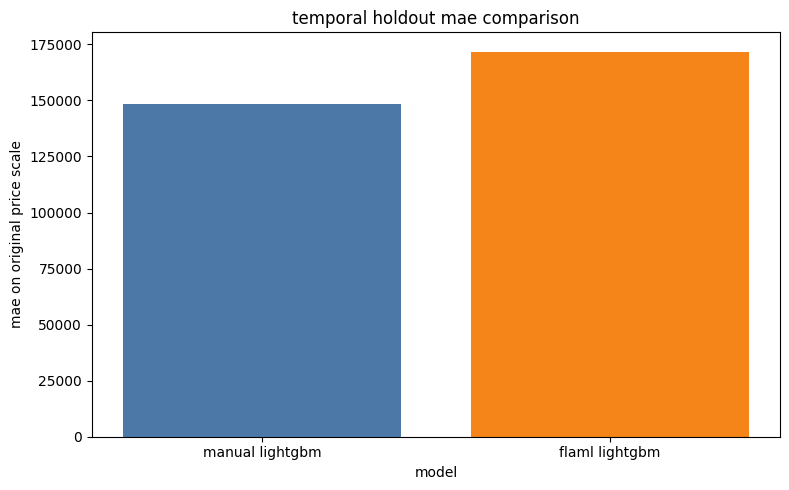

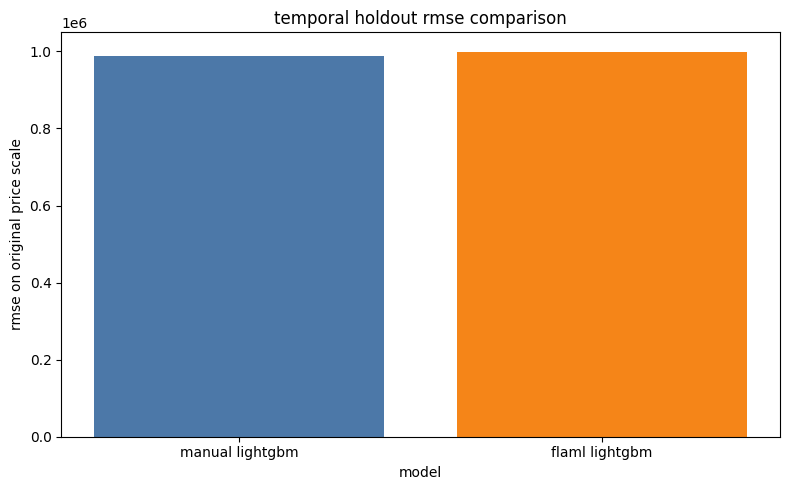

In [153]:
import matplotlib.pyplot as plt

model_colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(8, 5))
plt.bar(
    final_comparison_df_rounded["model"],
    final_comparison_df_rounded["mae_price"],
    color=model_colors
)
plt.title("temporal holdout mae comparison")
plt.xlabel("model")
plt.ylabel("mae on original price scale")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    final_comparison_df_rounded["model"],
    final_comparison_df_rounded["rmse_price"],
    color=model_colors
)
plt.title("temporal holdout rmse comparison")
plt.xlabel("model")
plt.ylabel("rmse on original price scale")
plt.tight_layout()
plt.show()

manual lightgbm has the lower temporal holdout mae at about £148k, compared with flaml lightgbm at about £171k.
that is a gap of roughly £23k, so the manual model is about 13% better on forward in time absolute error.
this matters because temporal holdout is a tougher and more realistic test than random validation.

manual lightgbm also wins on rmse, at about £0.99m versus roughly £1.00m for flaml lightgbm.
the gap is small, around £10k to £15k, which means both models still have similar exposure to large misses.
so the manual model is better, but not by a huge margin on tail error.

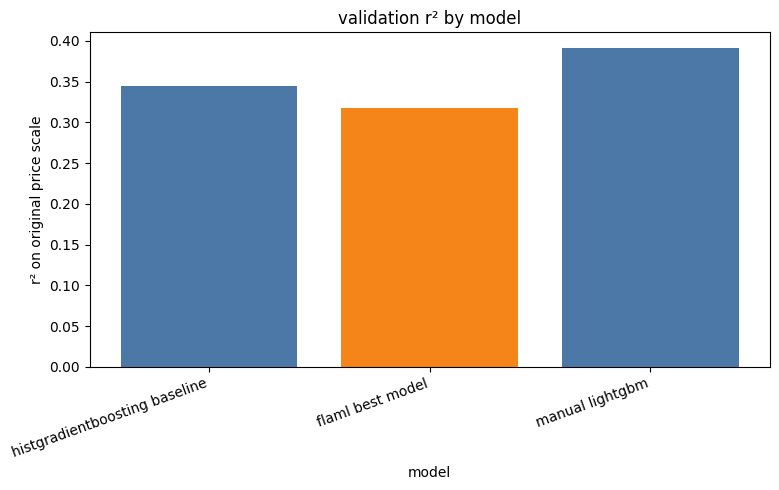

In [154]:
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df_rounded["model"],
    comparison_df_rounded["validation_r2_price"],
    color=model_colors
)
plt.title("validation r² by model")
plt.xlabel("model")
plt.ylabel("r² on original price scale")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

on validation, manual lightgbm is still best with r² around 0.39, ahead of the baseline near 0.34 and flaml best model near 0.32.
that gives the manual model about 0.05 more explained variance than the baseline and about 0.07 more than flaml.
so across fit quality, the manual setup is the strongest of the three.

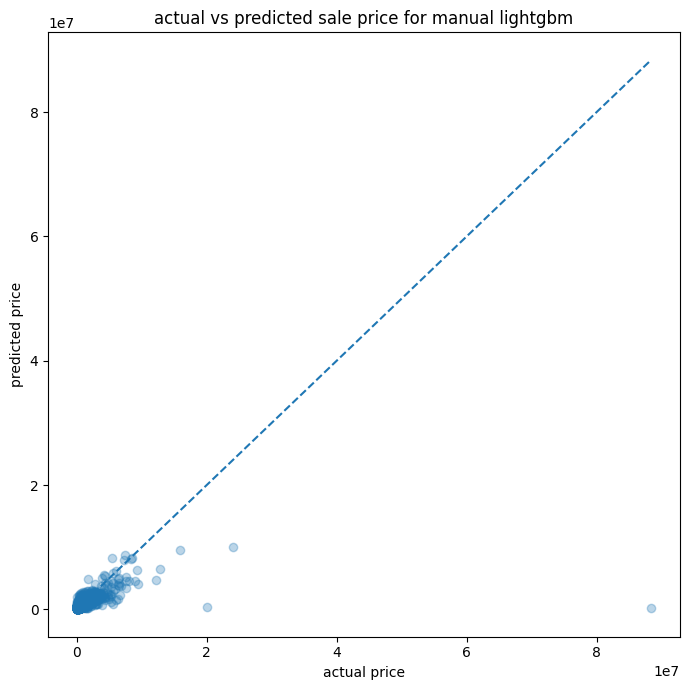

In [66]:
# checking how close predictions are to the ideal diagonal line
sample_size = 5000
scatter_idx = np.random.RandomState(42).choice(len(y_test_actual), size=sample_size, replace=False)

actual_sample = y_test_actual.iloc[scatter_idx]
pred_sample = y_test_pred_actual_lgbm[scatter_idx]

plt.figure(figsize=(7, 7))
plt.scatter(actual_sample, pred_sample, alpha=0.3)

min_val = min(actual_sample.min(), pred_sample.min())
max_val = max(actual_sample.max(), pred_sample.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("actual vs predicted sale price for manual lightgbm")
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.tight_layout()
plt.show()

most points cluster below £1m and many follow the diagonal reasonably well, so the model works better in the common price range.
for very expensive homes, points fall far below the diagonal, including one around £88m actual with almost £0 predicted, which is a severe underprediction.
this means calibration is decent in the lower range but breaks down badly in the luxury tail.

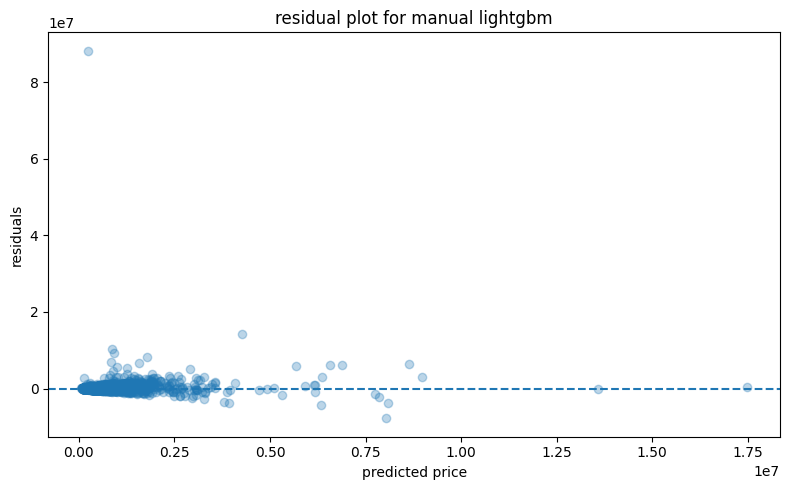

In [157]:
# i'm looking at where the model tends to overpredict and underpredict
residuals = y_test_actual - y_test_pred_actual_lgbm

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred_actual_lgbm[:5000], residuals[:5000], alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("residual plot for manual lightgbm")
plt.xlabel("predicted price")
plt.ylabel("residuals")
plt.tight_layout()
plt.show()

most predictions are centered close to the 0 residual line, but the spread clearly widens as predicted price rises, especially past about £2m to £3m.
there is one extreme positive residual near £88m, which means the model massively underpredicted at least one ultra expensive property.
there are some negative residuals too around £0.7m to £0.9m, but the biggest problem is underestimation in the top tail, not balanced random noise.

/tmp/ipykernel_13526/3399145211.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_mae = error_analysis_df.groupby("price_band")["absolute_error"].mean()


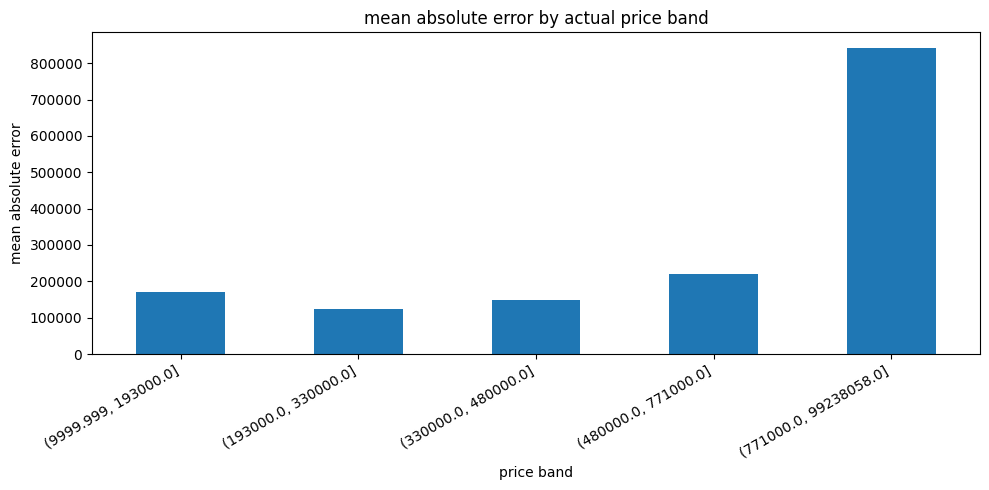

In [158]:
#checking to see if expensive homes cause bigger errors
error_analysis_df = pd.DataFrame({
    "actual_price": y_test_actual,
    "predicted_price": y_test_pred_actual_lgbm
})

error_analysis_df["absolute_error"] = abs(error_analysis_df["actual_price"] - error_analysis_df["predicted_price"])

error_analysis_df["price_band"] = pd.qcut(
    error_analysis_df["actual_price"],
    q=5,
    duplicates="drop"
)

band_mae = error_analysis_df.groupby("price_band")["absolute_error"].mean()

plt.figure(figsize=(10, 5))
band_mae.plot(kind="bar")
plt.title("mean absolute error by actual price band")
plt.xlabel("price band")
plt.ylabel("mean absolute error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

the model is best in the £193k to £330k band with mae around £120k, then worsens to about £150k in £330k to £480k and £220k in £480k to £771k.
the top band, £771k to £99.2m, jumps to about £840k, which is around 7x the error of the £193k to £330k band.
so error scales sharply with price, and the model becomes much less reliable once it moves into expensive properties.

### Overall Model Takeaway

these plots show the manual lightgbm is the best of the three models, but its gains are incremental rather than transformational, with r² only around 0.39 and mae still near £295k.
the model performs much better on normal priced homes than on expensive ones, with error jumping from about £120k in the £193k to £330k band to about £840k in the top band.
overall, the biggest weakness is clear underprediction and instability in the luxury tail, so the model is usable for mainstream properties but still unreliable for rare, ultra high value sales.

### Deployment Preperation

In [176]:
import joblib
import os

#saving the final project artifacts so i can reuse them for scoring later
artifact_folder = "/content/model_artifacts"
os.makedirs(artifact_folder, exist_ok=True)

joblib.dump(preprocessor, f"{artifact_folder}/preprocessor.joblib")
joblib.dump(lgbm_model, f"{artifact_folder}/manual_lightgbm_model.joblib")
joblib.dump(feature_cols, f"{artifact_folder}/feature_columns.joblib")

print("artifacts saved in:", artifact_folder)
print(os.listdir(artifact_folder))

artifacts saved in: /content/model_artifacts
['preprocessor.joblib', 'manual_lightgbm_model.joblib', '.ipynb_checkpoints', 'feature_columns.joblib']


In [177]:
import pandas as pd
import numpy as np
import joblib

#loading the saved artifacts the same way a deployment script would
loaded_preprocessor = joblib.load("/content/model_artifacts/preprocessor.joblib")
loaded_model = joblib.load("/content/model_artifacts/manual_lightgbm_model.joblib")
loaded_feature_cols = joblib.load("/content/model_artifacts/feature_columns.joblib")

print("number of saved features:", len(loaded_feature_cols))
print(loaded_feature_cols)

def score_new_data(input_data):
    input_df = pd.DataFrame(input_data).copy()
    input_df = input_df[loaded_feature_cols]

    input_processed = loaded_preprocessor.transform(input_df)
    pred_log = loaded_model.predict(input_processed)
    pred_price = np.expm1(pred_log)

    output_df = input_df.copy()
    output_df["predicted_history_price"] = pred_price
    return output_df

number of saved features: 20
['outcode', 'latitude', 'longitude', 'bathrooms', 'bedrooms', 'floorAreaSqM', 'livingRooms', 'tenure', 'propertyType', 'currentEnergyRating', 'rentEstimate_currentPrice', 'saleEstimate_currentPrice', 'saleEstimate_confidenceLevel', 'price_per_sqm_estimate', 'rent_yield_proxy', 'total_rooms', 'sqm_per_room', 'sale_estimate_range', 'history_year', 'history_month']


In [178]:
#esting the scoring function on a few known examples
sample_input = X_test.head(5).copy()
sample_predictions = score_new_data(sample_input)

display(sample_predictions)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,...,saleEstimate_currentPrice,saleEstimate_confidenceLevel,price_per_sqm_estimate,rent_yield_proxy,total_rooms,sqm_per_room,sale_estimate_range,history_year,history_month,predicted_history_price
355058,N11,51.607383,-0.131358,2.0,4.0,162.0,2.0,Freehold,Semi-Detached House,C,...,1169000.0,HIGH,7216.049383,0.044654,8.0,20.25,117000.0,2023,5,1.069110e+06
383150,SW15,51.457420,-0.219654,2.0,2.0,76.0,1.0,Leasehold,Purpose Built Flat,B,...,624000.0,HIGH,8210.526316,0.050962,5.0,15.20,62000.0,2023,11,5.981744e+05
279306,N11,51.630613,-0.149946,1.0,3.0,102.0,2.0,Freehold,Semi-Detached House,E,...,710000.0,HIGH,6960.784314,0.044789,6.0,17.00,71000.0,2021,6,6.238120e+05
378822,SE18,51.476580,0.070274,1.0,3.0,84.0,2.0,Freehold,Semi-Detached House,D,...,619000.0,HIGH,7369.047619,0.050404,6.0,14.00,62000.0,2023,10,5.653714e+05
64842,SW16,51.436970,-0.136277,1.0,2.0,85.0,1.0,Leasehold,Converted Flat,D,...,675000.0,HIGH,7941.176471,0.053333,4.0,21.25,68000.0,2001,8,2.029530e+05


In [180]:
score_py = '''
import pandas as pd
import numpy as np
import joblib

preprocessor = joblib.load("model_artifacts/preprocessor.joblib")
model = joblib.load("model_artifacts/manual_lightgbm_model.joblib")
feature_cols = joblib.load("model_artifacts/feature_columns.joblib")

def score_new_data(input_data):
    input_df = pd.DataFrame(input_data)
    input_df = input_df[feature_cols]

    input_processed = preprocessor.transform(input_df)
    pred_log = model.predict(input_processed)
    pred_price = np.expm1(pred_log)

    output_df = input_df.copy()
    output_df["predicted_history_price"] = pred_price

    return output_df

if __name__ == "__main__":
    sample_data = [
        {
            "outcode": "SW2",
            "latitude": 51.45,
            "longitude": -0.12,
            "bathrooms": 1.0,
            "bedrooms": 2.0,
            "floorAreaSqM": 75.0,
            "livingRooms": 1.0,
            "tenure": "Leasehold",
            "propertyType": "Flat/Maisonette",
            "currentEnergyRating": "C",
            "rentEstimate_currentPrice": 2200.0,
            "saleEstimate_currentPrice": 450000.0,
            "saleEstimate_confidenceLevel": "HIGH"
        }
    ]

    predictions = score_new_data(sample_data)
    print(predictions)
'''

In [181]:
#im writing the deployment-style scoring script to a file
with open("/content/model_artifacts/score.py", "w") as f:
    f.write(score_py)

print("score.py created successfully")

score.py created successfully


In [182]:
print(os.listdir("/content/model_artifacts"))

['preprocessor.joblib', 'manual_lightgbm_model.joblib', '.ipynb_checkpoints', 'score.py', 'feature_columns.joblib']


In [183]:
with open("/content/model_artifacts/score.py", "r") as f:
    print(f.read())


import pandas as pd
import numpy as np
import joblib

preprocessor = joblib.load("model_artifacts/preprocessor.joblib")
model = joblib.load("model_artifacts/manual_lightgbm_model.joblib")
feature_cols = joblib.load("model_artifacts/feature_columns.joblib")

def score_new_data(input_data):
    input_df = pd.DataFrame(input_data)
    input_df = input_df[feature_cols]
    
    input_processed = preprocessor.transform(input_df)
    pred_log = model.predict(input_processed)
    pred_price = np.expm1(pred_log)
    
    output_df = input_df.copy()
    output_df["predicted_history_price"] = pred_price
    
    return output_df

if __name__ == "__main__":
    sample_data = [
        {
            "outcode": "SW2",
            "latitude": 51.45,
            "longitude": -0.12,
            "bathrooms": 1.0,
            "bedrooms": 2.0,
            "floorAreaSqM": 75.0,
            "livingRooms": 1.0,
            "tenure": "Leasehold",
            "propertyType": "Flat/Maisonette",
            "c

the packaging step is meant to be demonstrated from within the notebook, so the cleanest approach is to generate the deployment files directly from the same workflow that trained the model. this keeps everything reproducible and makes it easier to show that the saved model, preprocessor, and scoring script all belong to the same final pipeline. once created, the score.py file can then be exported and added to the project repository as part of the deliverables.

In [184]:
import pandas as pd
import numpy as np
import joblib

# loading the saved artifacts to prove the packaged version works
loaded_preprocessor = joblib.load("/content/model_artifacts/preprocessor.joblib")
loaded_model = joblib.load("/content/model_artifacts/manual_lightgbm_model.joblib")
loaded_feature_cols = joblib.load("/content/model_artifacts/feature_columns.joblib")

def score_new_data(input_data):
    input_df = pd.DataFrame(input_data)
    input_df = input_df[loaded_feature_cols]

    input_processed = loaded_preprocessor.transform(input_df)
    pred_log = loaded_model.predict(input_processed)
    pred_price = np.expm1(pred_log)

    output_df = input_df.copy()
    output_df["predicted_history_price"] = pred_price

    return output_df

#testing the packaged scoring flow on a few unseen rows
sample_input = X_test.head(5).copy()
scored_output = score_new_data(sample_input)

display(scored_output)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,tenure,propertyType,currentEnergyRating,...,saleEstimate_currentPrice,saleEstimate_confidenceLevel,price_per_sqm_estimate,rent_yield_proxy,total_rooms,sqm_per_room,sale_estimate_range,history_year,history_month,predicted_history_price
355058,N11,51.607383,-0.131358,2.0,4.0,162.0,2.0,Freehold,Semi-Detached House,C,...,1169000.0,HIGH,7216.049383,0.044654,8.0,20.25,117000.0,2023,5,1.069110e+06
383150,SW15,51.457420,-0.219654,2.0,2.0,76.0,1.0,Leasehold,Purpose Built Flat,B,...,624000.0,HIGH,8210.526316,0.050962,5.0,15.20,62000.0,2023,11,5.981744e+05
279306,N11,51.630613,-0.149946,1.0,3.0,102.0,2.0,Freehold,Semi-Detached House,E,...,710000.0,HIGH,6960.784314,0.044789,6.0,17.00,71000.0,2021,6,6.238120e+05
378822,SE18,51.476580,0.070274,1.0,3.0,84.0,2.0,Freehold,Semi-Detached House,D,...,619000.0,HIGH,7369.047619,0.050404,6.0,14.00,62000.0,2023,10,5.653714e+05
64842,SW16,51.436970,-0.136277,1.0,2.0,85.0,1.0,Leasehold,Converted Flat,D,...,675000.0,HIGH,7941.176471,0.053333,4.0,21.25,68000.0,2001,8,2.029530e+05


In [185]:
#comparing packaged predictions with actual prices to show the script works end to end
sample_actual = np.expm1(y_test.iloc[:5]).values

scored_output["actual_history_price"] = sample_actual
scored_output["absolute_error"] = abs(
    scored_output["actual_history_price"] - scored_output["predicted_history_price"]
)

display(scored_output[[
    "predicted_history_price",
    "actual_history_price",
    "absolute_error"
]])

,predicted_history_price,actual_history_price,absolute_error
355058,1.069110e+06,1100000.0,30890.170141
383150,5.981744e+05,560000.0,38174.436184
279306,6.238120e+05,622200.0,1612.026142
378822,5.653714e+05,600000.0,34628.568253
64842,2.029530e+05,130000.0,72953.032023


In [186]:
with open("/content/model_artifacts/score.py", "r") as f:
    print(f.read()[:1000])


import pandas as pd
import numpy as np
import joblib

preprocessor = joblib.load("model_artifacts/preprocessor.joblib")
model = joblib.load("model_artifacts/manual_lightgbm_model.joblib")
feature_cols = joblib.load("model_artifacts/feature_columns.joblib")

def score_new_data(input_data):
    input_df = pd.DataFrame(input_data)
    input_df = input_df[feature_cols]
    
    input_processed = preprocessor.transform(input_df)
    pred_log = model.predict(input_processed)
    pred_price = np.expm1(pred_log)
    
    output_df = input_df.copy()
    output_df["predicted_history_price"] = pred_price
    
    return output_df

if __name__ == "__main__":
    sample_data = [
        {
            "outcode": "SW2",
            "latitude": 51.45,
            "longitude": -0.12,
            "bathrooms": 1.0,
            "bedrooms": 2.0,
            "floorAreaSqM": 75.0,
            "livingRooms": 1.0,
            "tenure": "Leasehold",
            "propertyType": "Flat/Maisonette",
            "c

the deployment test should demonstrate that the final model can be reused outside the training flow by loading the saved artifacts and generating predictions on new input records. showing both the predicted prices and the matching actual prices in the notebook makes the packaging step more convincing, because it proves the saved pipeline is functional end to end rather than just stored on disk. this gives clear evidence that the model is ready for practical scoring and satisfies the project’s deployment-preparation requirement.

## Closing Statement

the final pipeline reorganized the original housing dataset into three business-focused tables representing property characteristics, market estimates, and transaction history, which made the overall structure clearer and more aligned with the project requirements. after improving the feature set and comparing baseline, automl, and manual approaches, the manually tuned lightgbm model remained the strongest overall choice and performed best under the temporal holdout evaluation, which became the most realistic measure of generalization in this project. shap analysis and grouped error analysis helped explain which variables were driving the predictions and also showed that errors remained higher in premium areas and for more expensive or less common property types. finally, the packaging step confirmed that the selected model, preprocessing pipeline, and scoring script could be saved and reused for practical prediction on new property records.

In [187]:
import shutil
shutil.make_archive("/content/model_artifacts", "zip", "/content/model_artifacts")
shutil.make_archive("/content/split_tables", "zip", "/content/split_tables")

'/content/split_tables.zip'

In [188]:
from google.colab import files

files.download("/content/model_artifacts.zip")
files.download("/content/split_tables.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>